# M2 summary-dimension PMP diagnostics

Combine the saved OOD diagnostic results for `m2_s_20d_10n`, `m2_s_40d_10n`, and `m2_s_80d_10n` into shared-panel figures.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from benchmark.examples.gaussian.analysis import summry_diagnostic as sd


In [ ]:
project_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
result_dir = project_dir / "results"

summary_specs = [
    ("S=D", "20d_10n", result_dir / "ood_20d_10n"),
    ("S=2D", "40d_10n", result_dir / "ood_40d_10n"),
    ("S=4D", "80d_10n", result_dir / "ood_80d_10n"),
]

pmp_by_summary = {
    label: pd.read_csv(path / f"pmp_ambiguity_frame_{tag}.csv")
    for label, tag, path in summary_specs
}
logml_by_summary = {
    label: pd.read_csv(path / f"logml_distance_frame_{tag}.csv")
    for label, tag, path in summary_specs
}
posterior_by_summary = {
    label: pd.read_csv(path / f"posterior_distance_frame_{tag}.csv")
    for label, tag, path in summary_specs
}

for label, df in pmp_by_summary.items():
    print(
        label,
        "pmp", df.shape,
        "logml", logml_by_summary[label].shape,
        "posterior", posterior_by_summary[label].shape,
    )

In [13]:
source_color = dict(zip(sd.SOURCE_MODELS, sd.SOURCE_COLORS, strict=False))
class_styles = {
    False: {"marker": "o", "size": 32, "label": "all high surprise"},
    True: {"marker": "D", "size": 48, "label": "at least one not high surprise"},
}


def ensure_logA_thresholds(data, alpha=0.05):
    out = data.copy()
    if "ambiguity_score_true" not in out:
        out["ambiguity_score_true"] = 1.0 / (np.abs(out["d_second"] - out["d_min"]) + 1e-8)
    if {"logA_low", "logA_high"}.issubset(out.columns) and out["logA_high"].notna().any():
        return out
    # Existing CSVs were created before reference-calibration A_true thresholds were saved.
    logA_true = np.log1p(out["ambiguity_score_true"])
    out["logA_low"] = float(np.quantile(logA_true, alpha / 2))
    out["logA_high"] = float(np.quantile(logA_true, 1 - alpha / 2))
    out["logA_median"] = float(np.median(logA_true))
    return out


pmp_by_summary = {label: ensure_logA_thresholds(df) for label, df in pmp_by_summary.items()}


def scatter_by_class_and_source(ax, data, x, y):
    for flag, style in class_styles.items():
        group = data[data["at_least_one_not_extrapolative"] == flag]
        ax.scatter(
            x.loc[group.index],
            y.loc[group.index],
            c=group["source_model"].map(source_color),
            marker=style["marker"],
            s=style["size"],
            alpha=0.75,
            edgecolors="black",
            linewidths=0.55,
        )


def add_first_large_error(ax, data, x, y, error_bound=0.05):
    if error_bound is None or data.empty:
        return
    ordered = pd.DataFrame({"x": x.loc[data.index], "y": y.loc[data.index]}).dropna().sort_values("x")
    hit = ordered[np.abs(ordered["y"]) > error_bound].head(1)
    if hit.empty:
        return
    x0 = float(hit["x"].iloc[0])
    ax.axvline(x0, color="0.2", linestyle=":", linewidth=1.2)
    ax.text(x0, 0.96, f"{x0:.2g}", transform=ax.get_xaxis_transform(), ha="right", va="top", rotation=90, fontsize=20)


def add_distance_regions(ax, low, high, x_min, x_max):
    ax.axvspan(x_min, low, color=sd.REGIME_COLORS["interpolation"], alpha=0.08)
    ax.axvspan(low, high, color=sd.REGIME_COLORS["in_distribution"], alpha=0.07)
    ax.axvspan(high, x_max, color=sd.REGIME_COLORS["extrapolation"], alpha=0.07)
    ax.axvline(low, color=sd.REGIME_COLORS["interpolation"], linestyle="--", linewidth=1)
    ax.axvline(high, color=sd.REGIME_COLORS["extrapolation"], linestyle="--", linewidth=1)


def add_A_regions(ax, data, x_min, x_max):
    low = float(data["logA_low"].dropna().iloc[0])
    high = float(data["logA_high"].dropna().iloc[0])
    add_distance_regions(ax, low, high, x_min, x_max)


def add_facet_strips(fig, axes, col_labels=None, row_labels=None):
    axes = np.atleast_2d(axes)
    strip_color = "0.85"
    edge_color = "0.35"
    pad = 0.004
    top_h = 0.034
    right_w = 0.052

    if col_labels is not None:
        for ax, label in zip(axes[0], col_labels, strict=False):
            pos = ax.get_position()
            strip = fig.add_axes([pos.x0, pos.y1 + pad, pos.width, top_h])
            strip.set_facecolor(strip_color)
            strip.text(0.5, 0.5, label, ha="center", va="center", fontsize=18)
            strip.set_xticks([])
            strip.set_yticks([])
            for spine in strip.spines.values():
                spine.set_color(edge_color)

    if row_labels is not None:
        for ax, label in zip(axes[:, -1], row_labels, strict=False):
            pos = ax.get_position()
            strip = fig.add_axes([pos.x1 + pad, pos.y0, right_w, pos.height])
            strip.set_facecolor(strip_color)
            strip.text(0.5, 0.5, label, rotation=-90, ha="center", va="center", fontsize=16, linespacing=1.05)
            strip.set_xticks([])
            strip.set_yticks([])
            for spine in strip.spines.values():
                spine.set_color(edge_color)


def legend_handles():
    class_handles = [
        Line2D([0], [0], marker=style["marker"], color="none", markerfacecolor="0.55", markeredgecolor="black", markersize=9, label=style["label"])
        for style in class_styles.values()
    ]
    model_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=source_color[source], markeredgecolor="black", markersize=9, label=source.upper())
        for source in sd.SOURCE_MODELS
    ]
    return class_handles, model_handles


def add_bottom_legend(fig, include_class=True):
    class_handles, model_handles = legend_handles()
    if include_class:
        fig.legend(handles=class_handles, loc="lower center", bbox_to_anchor=(0.5, 0.075), ncol=2, frameon=False, fontsize=17)
        model_y = 0.0
    else:
        model_y = 0.035
    fig.legend(handles=model_handles, loc="lower center", bbox_to_anchor=(0.5, model_y), ncol=len(sd.SOURCE_MODELS), frameon=False, fontsize=17)


def add_right_legend(fig, x=0.84):
    class_handles, model_handles = legend_handles()
    fig.legend(handles=class_handles, loc="center left", bbox_to_anchor=(x, 0.62), ncol=1, frameon=False, fontsize=17)
    fig.legend(handles=model_handles, loc="center left", bbox_to_anchor=(x, 0.34), ncol=2, frameon=False, fontsize=17)


def style_panel_grid(fig, axes, xlabel_by_col, ylabel, row_labels, col_labels, include_class_legend=True):
    axes = np.atleast_2d(axes)
    for ax in axes.ravel():
        ax.grid(alpha=0.2)
        ax.tick_params(labelsize=16)
        ax.xaxis.label.set_size(18)
        ax.yaxis.label.set_size(18)

    for ax, xlabel in zip(axes[-1], xlabel_by_col, strict=False):
        ax.set_xlabel(xlabel)

    fig.supylabel(ylabel, x=0.035, fontsize=20)
    add_facet_strips(fig, axes, col_labels=col_labels, row_labels=row_labels)
    add_bottom_legend(fig, include_class=include_class_legend)


Truncated rho above the 99% quantile: rho > 7.684


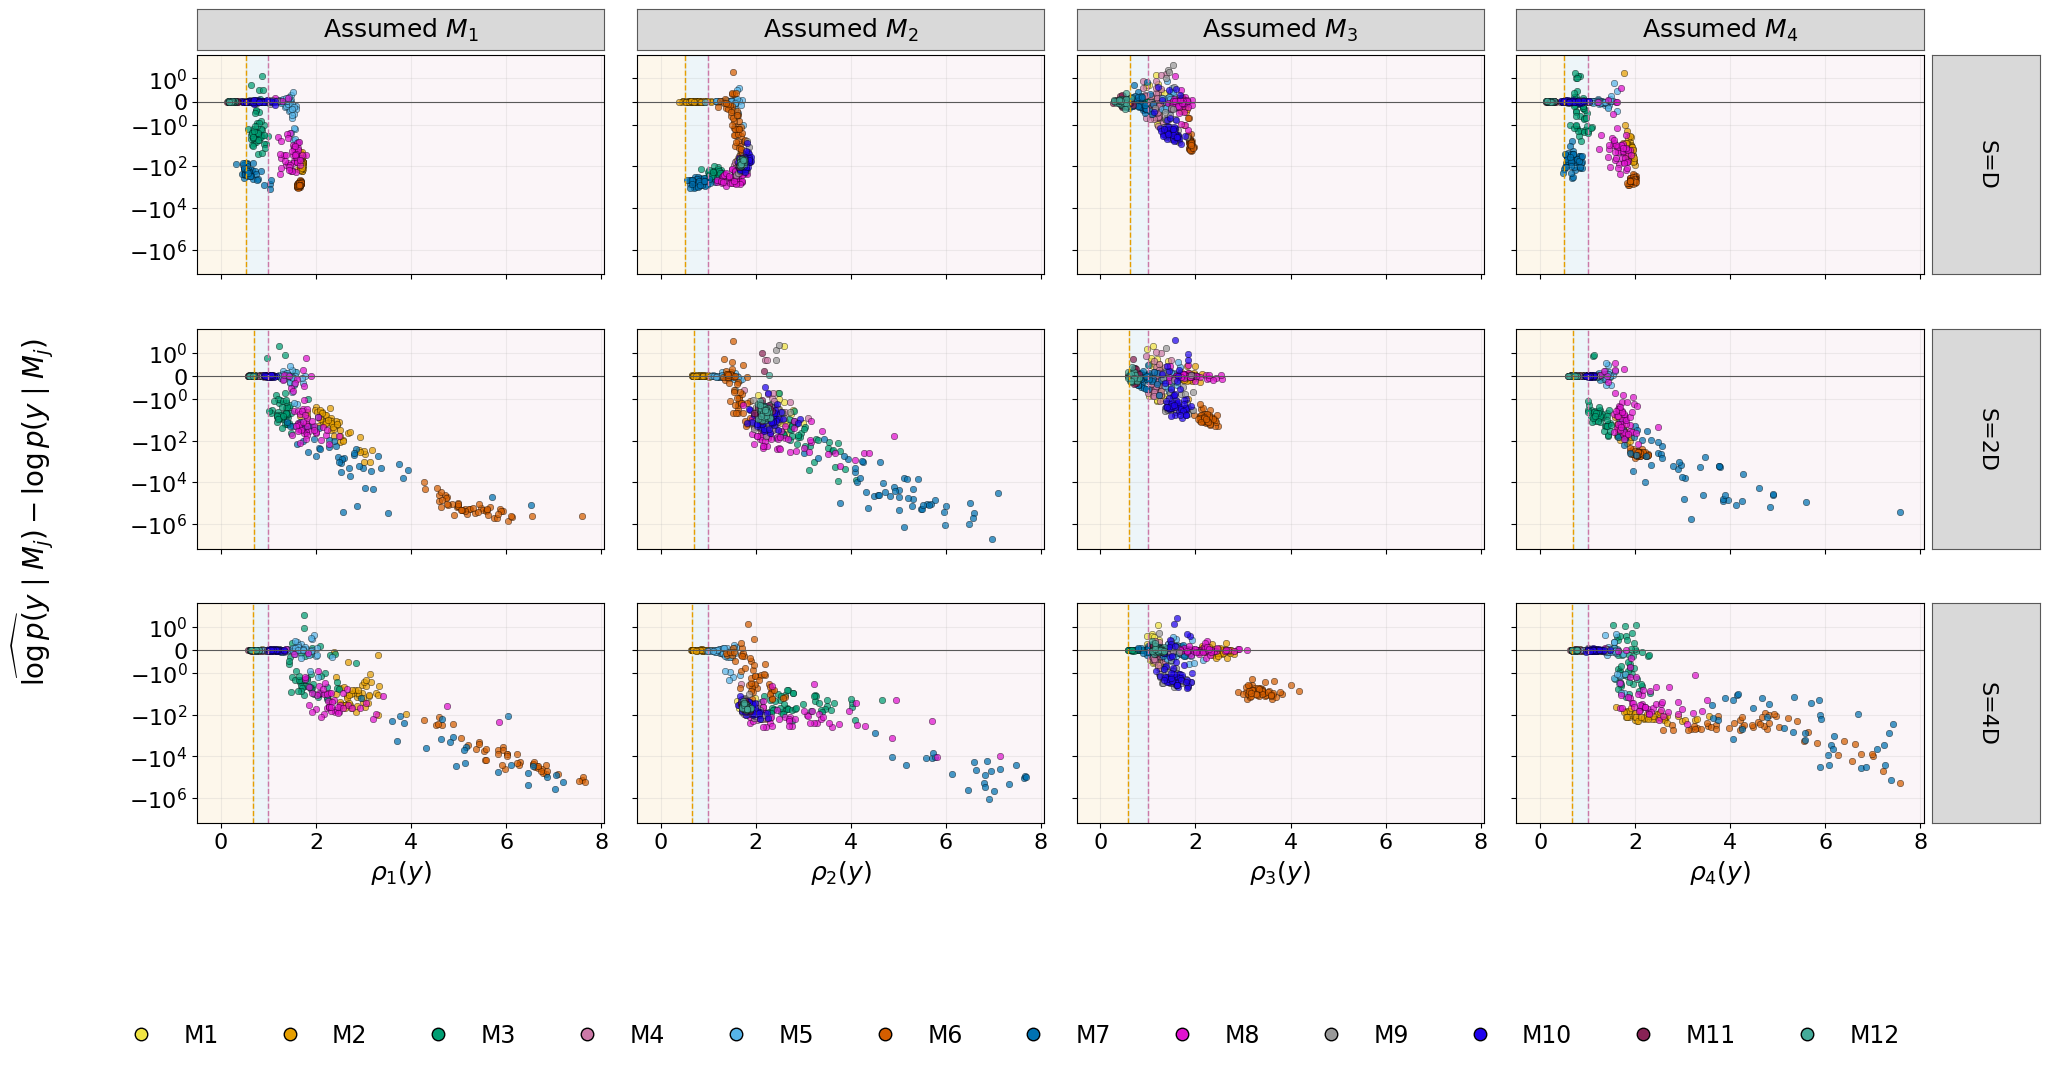

In [14]:
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator


def _signed_power_formatter(value, pos=None):
    if np.isclose(value, 0.0):
        return "0"
    sign = "-" if value < 0 else ""
    abs_value = abs(value)
    exponent = int(np.round(np.log10(abs_value)))
    if np.isclose(abs_value, 10**exponent):
        return rf"${sign}10^{{{exponent}}}$"
    return f"{value:g}"


def _symlog_ticks(y_min, y_max):
    ticks = [0.0]
    if y_min < 0:
        min_exp = int(np.floor(np.log10(abs(y_min))))
        neg_exps = list(range(min_exp, -1, -2))
        ticks.extend([-10.0**exp for exp in neg_exps])
        ticks.append(-1.0)
    if y_max > 0:
        max_exp = int(np.floor(np.log10(y_max)))
        ticks.extend([10.0**exp for exp in range(0, max_exp + 1, 2)])
    return sorted(set(t for t in ticks if y_min <= t <= y_max))


def plot_combined_logml_rho_error(logml_by_summary, error_bound=None, upper_quantile=0.99):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(logml_by_summary)
    col_labels = [rf"Assumed $M_{model[1:]}$" for model in assumed_models]
    x_min = -0.5

    all_rho = []
    for data in logml_by_summary.values():
        all_rho.append((data["d_M"] / data["dm_high"]).to_numpy(float))
    rho_cutoff = float(np.quantile(np.concatenate(all_rho), upper_quantile))
    x_max = rho_cutoff * 1.05

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 4 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    fig.subplots_adjust(left=0.11, right=0.94, bottom=0.24, top=0.88, wspace=0.08, hspace=0.25)

    plotted_y = []
    for r, (row_label, data) in enumerate(logml_by_summary.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            sub = data[data["assumed_model"] == model].copy()
            rho = sub["d_M"] / sub["dm_high"]
            keep = rho <= rho_cutoff
            sub = sub.loc[keep].copy()
            rho = rho.loc[keep]
            plotted_y.append(sub["signed_logml_error"].to_numpy(float))

            low = float((sub["dm_low"] / sub["dm_high"]).iloc[0])
            add_distance_regions(ax, low=low, high=1.0, x_min=x_min, x_max=x_max)
            for source in sd.SOURCE_MODELS:
                group = sub[sub["source_model"] == source]
                ax.scatter(
                    rho.loc[group.index],
                    group["signed_logml_error"],
                    color=source_color[source],
                    s=22,
                    alpha=0.72,
                    edgecolors="black",
                    linewidths=0.35,
                )
            add_first_large_error(ax, sub, rho, sub["signed_logml_error"], error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_yscale("symlog", linthresh=1.0)
            ax.set_xlim(x_min, x_max)

    y_values = np.concatenate(plotted_y)
    y_min, y_max = float(np.nanmin(y_values)), float(np.nanmax(y_values))
    ticks = _symlog_ticks(y_min, y_max)
    for ax in axes.ravel():
        ax.yaxis.set_major_locator(FixedLocator(ticks))
        ax.yaxis.set_major_formatter(FuncFormatter(_signed_power_formatter))
        ax.yaxis.set_minor_locator(NullLocator())
        ax.yaxis.get_offset_text().set_visible(False)

    xlabel_by_col = [rf"$\rho_{model[1:]}(y)$" for model in assumed_models]
    style_panel_grid(
        fig,
        axes,
        xlabel_by_col,
        "",
        row_labels,
        col_labels,
        include_class_legend=False,
    )
    fig.supylabel(r"$\widehat{\log p}(y\mid M_j)-\log p(y\mid M_j)$", x=0.02, fontsize=20)
    print(f"Truncated rho above the {upper_quantile:.0%} quantile: rho > {rho_cutoff:.3f}")
    return fig, axes, rho_cutoff


fig_logml_rho, axes_logml_rho, logml_rho_cutoff = plot_combined_logml_rho_error(logml_by_summary)

In [ ]:
def plot_combined_posterior_mmd_rho(posterior_by_summary, upper_quantile=0.99, metric="posterior_mmd"):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(posterior_by_summary)
    col_labels = [rf"Assumed $M_{model[1:]}$" for model in assumed_models]
    x_min = -0.5

    all_rho = []
    for data in posterior_by_summary.values():
        all_rho.append((data["d_M"] / data["dm_high"]).to_numpy(float))
    rho_cutoff = float(np.quantile(np.concatenate(all_rho), upper_quantile))
    x_max = rho_cutoff * 1.05

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 4 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.11, right=0.94, bottom=0.24, top=0.88, wspace=0.08, hspace=0.25)

    for r, (row_label, data) in enumerate(posterior_by_summary.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            sub = data[data["assumed_model"] == model].copy()
            rho = sub["d_M"] / sub["dm_high"]
            keep = rho <= rho_cutoff
            sub = sub.loc[keep].copy()
            rho = rho.loc[keep]

            low = float((sub["dm_low"] / sub["dm_high"]).iloc[0])
            add_distance_regions(ax, low=low, high=1.0, x_min=x_min, x_max=x_max)
            for source in sd.SOURCE_MODELS:
                group = sub[sub["source_model"] == source]
                ax.scatter(
                    rho.loc[group.index],
                    group[metric],
                    color=source_color[source],
                    s=22,
                    alpha=0.72,
                    edgecolors="black",
                    linewidths=0.35,
                )
            ax.set_xlim(x_min, x_max)

    xlabel_by_col = [rf"$\rho_{model[1:]}(y)$" for model in assumed_models]
    style_panel_grid(
        fig,
        axes,
        xlabel_by_col,
        "Posterior MMD",
        row_labels,
        col_labels,
        include_class_legend=False,
    )
    print(f"Truncated rho above the {upper_quantile:.0%} quantile: rho > {rho_cutoff:.3f}")
    return fig, axes, rho_cutoff


fig_posterior_mmd_rho, axes_posterior_mmd_rho, posterior_mmd_rho_cutoff = plot_combined_posterior_mmd_rho(posterior_by_summary)

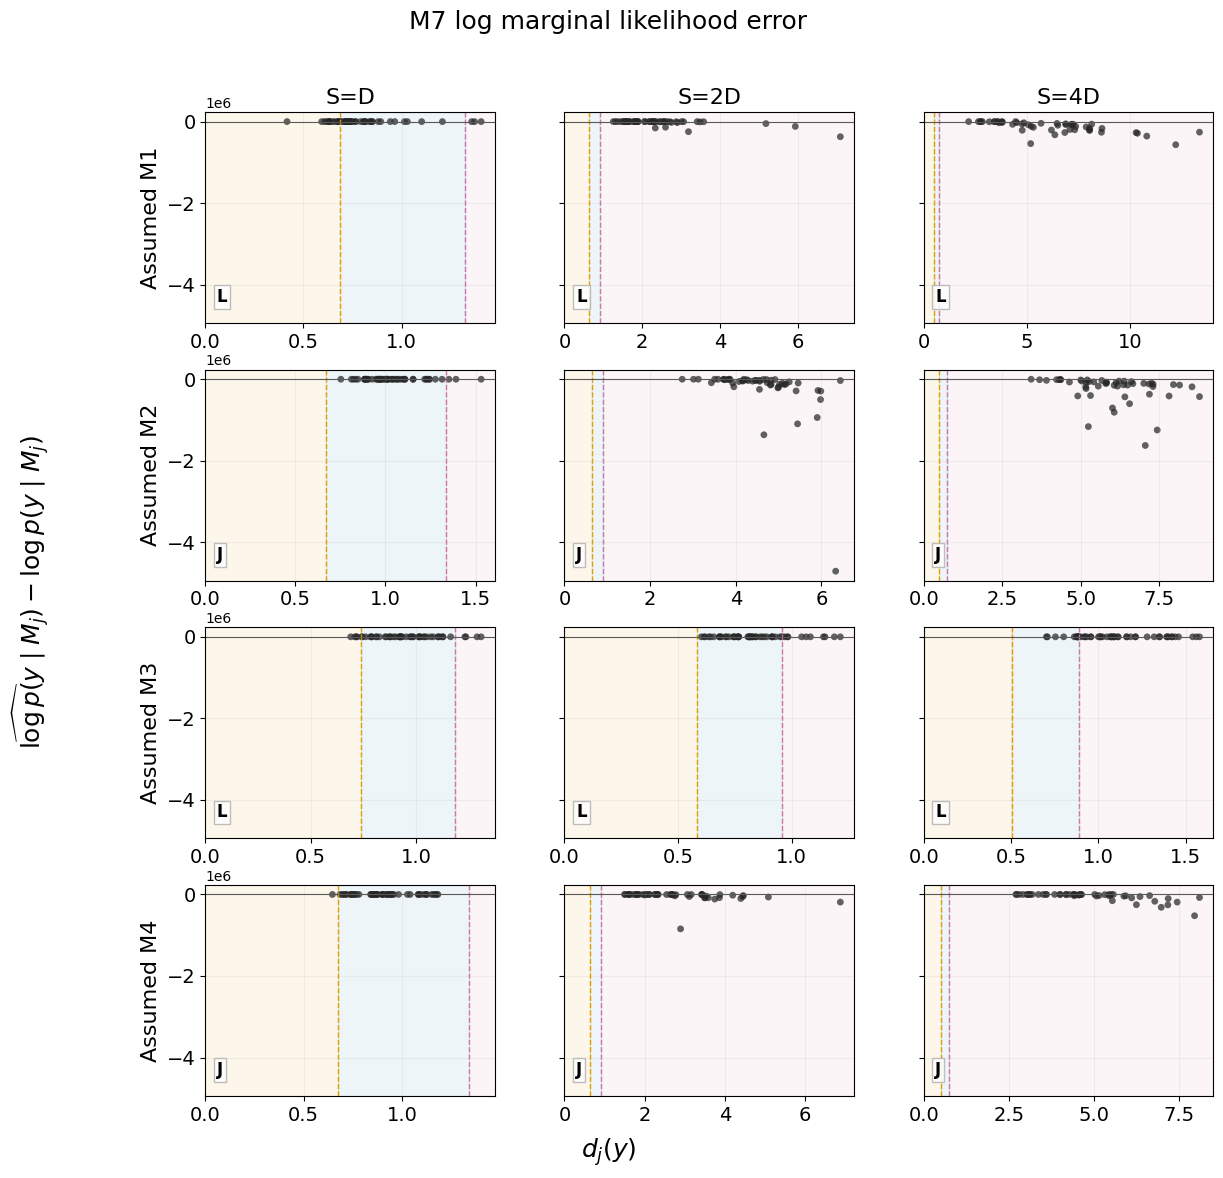

In [ ]:
def plot_m7_logml_error_grid(logml_by_summary, source_model="m7", error_bound=None):
    assumed_models = sd.ASSUMED_MODELS
    summary_labels = list(logml_by_summary)
    fig, axes = plt.subplots(
        len(assumed_models),
        len(summary_labels),
        figsize=(4.2 * len(summary_labels), 3 * len(assumed_models)),
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.18, right=0.98, bottom=0.08, top=0.90, wspace=0.24, hspace=0.22)

    for r, model in enumerate(assumed_models):
        for c, summary_label in enumerate(summary_labels):
            ax = axes[r, c]
            data = logml_by_summary[summary_label]
            sub = data[(data["source_model"] == source_model) & (data["assumed_model"] == model)].copy()
            low = float(sub["dm_low"].iloc[0])
            high = float(sub["dm_high"].iloc[0])
            x_max = max(float(sub["d_M"].max()) * 1.05, high * 1.1)

            add_distance_regions(ax, low=low, high=high, x_min=0.0, x_max=x_max)
            ax.scatter(
                sub["d_M"],
                sub["signed_logml_error"],
                s=24,
                color="0.15",
                alpha=0.72,
                edgecolors="none",
            )
            add_first_large_error(ax, sub, sub["d_M"], sub["signed_logml_error"], error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xlim(0.0, x_max)
            ax.grid(alpha=0.16)

            misspec = sd.MISSPEC_LABELS.get(model, {}).get(source_model, "")
            if misspec:
                ax.text(
                    0.04,
                    0.08,
                    misspec,
                    transform=ax.transAxes,
                    ha="left",
                    va="bottom",
                    fontsize=12,
                    fontweight="bold",
                    bbox={"facecolor": "white", "edgecolor": "0.7", "alpha": 0.85, "pad": 2},
                )

            if r == 0:
                ax.set_title(summary_label)
            if c == 0:
                ax.set_ylabel(f"Assumed {model.upper()}")
            

    for ax in axes.ravel():
        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(16)
        ax.yaxis.label.set_size(16)
        ax.title.set_fontsize(16)

    fig.supylabel(r"$\widehat{\log p}(y\mid M_j)-\log p(y\mid M_j)$", x=0.025, fontsize=18)
    fig.supxlabel(r"$d_j(y)$", y=0.02, fontsize=18)
    fig.suptitle(f"{source_model.upper()} log marginal likelihood error", y=0.985, fontsize=18)
    return fig, axes


fig_m7_logml_error, axes_m7_logml_error = plot_m7_logml_error_grid(logml_by_summary)

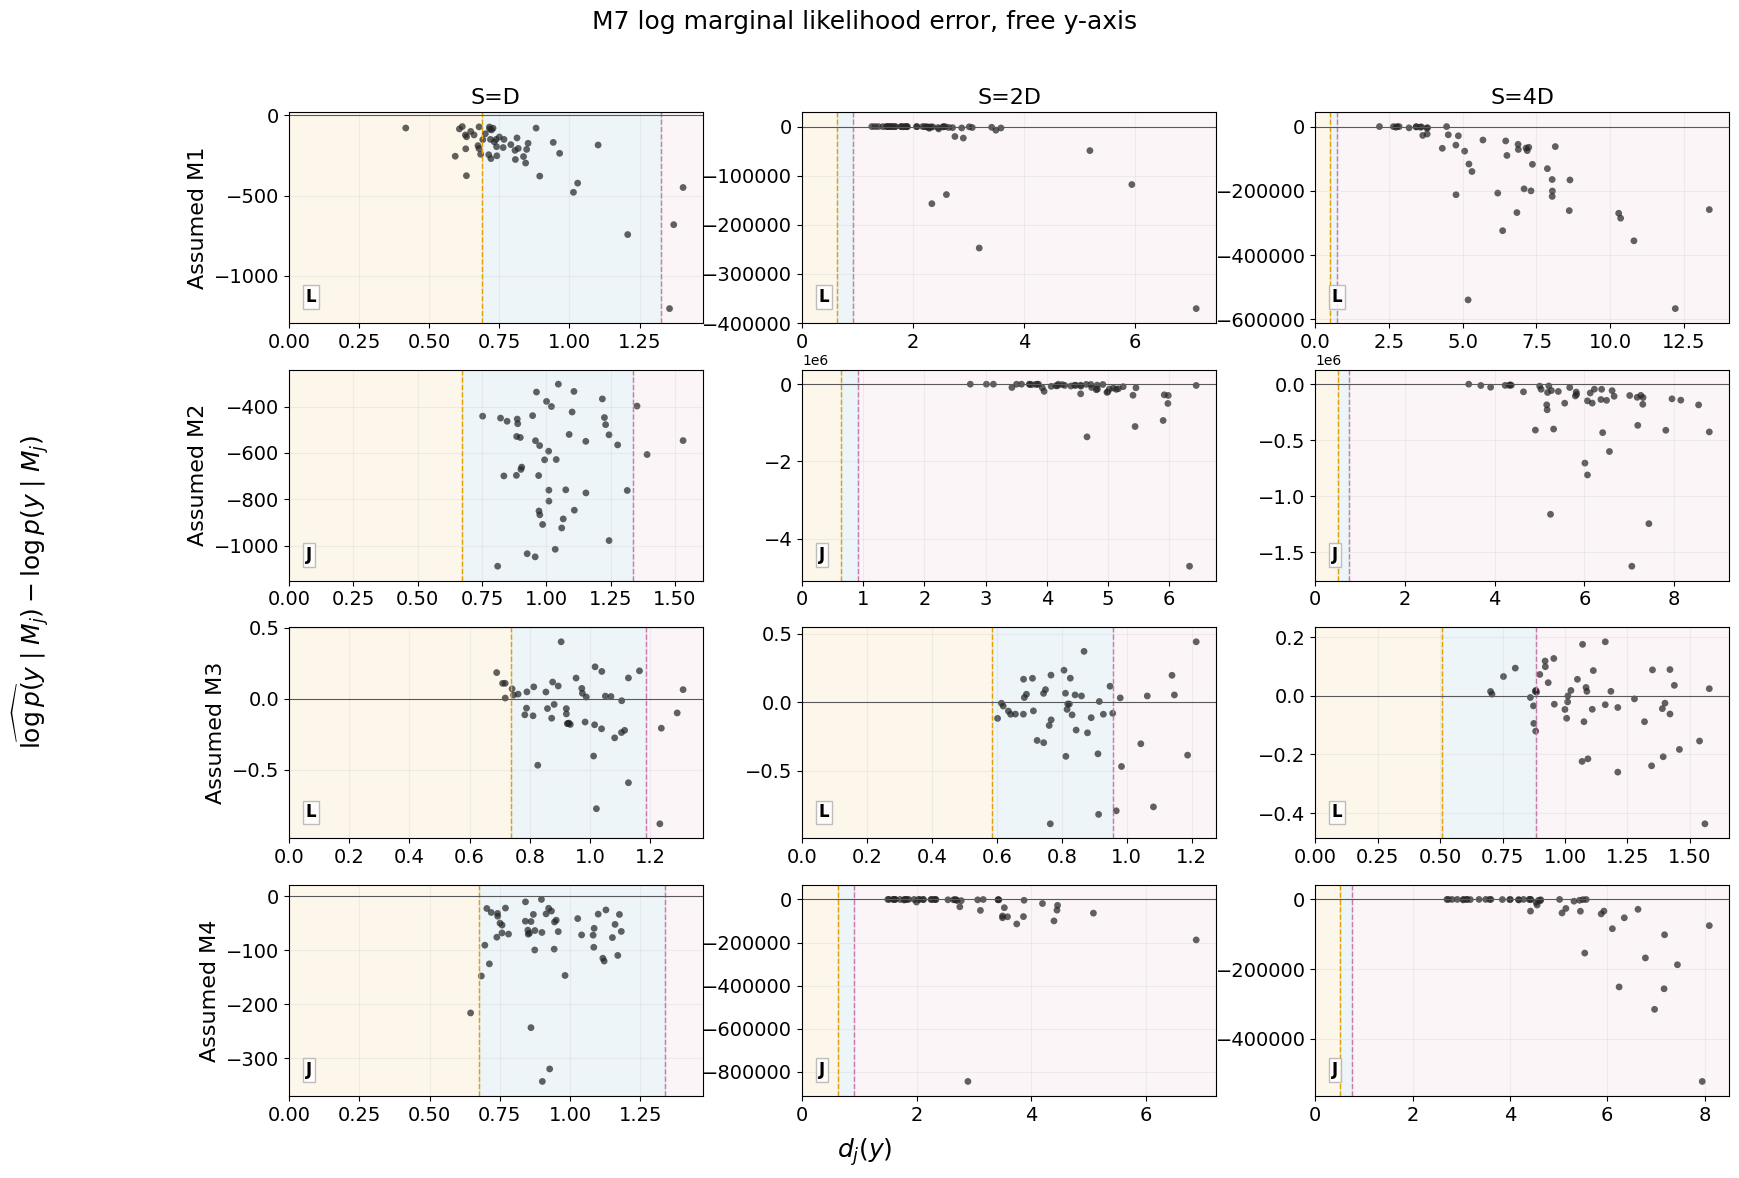

In [ ]:
def plot_m7_logml_error_grid_free_y(logml_by_summary, source_model="m7", error_bound=None):
    assumed_models = sd.ASSUMED_MODELS
    summary_labels = list(logml_by_summary)
    fig, axes = plt.subplots(
        len(assumed_models),
        len(summary_labels),
        figsize=(6 * len(summary_labels), 3.0 * len(assumed_models)),
        sharey=False,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.18, right=0.98, bottom=0.08, top=0.90, wspace=0.24, hspace=0.22)

    for r, model in enumerate(assumed_models):
        for c, summary_label in enumerate(summary_labels):
            ax = axes[r, c]
            data = logml_by_summary[summary_label]
            sub = data[(data["source_model"] == source_model) & (data["assumed_model"] == model)].copy()
            low = float(sub["dm_low"].iloc[0])
            high = float(sub["dm_high"].iloc[0])
            x_max = max(float(sub["d_M"].max()) * 1.05, high * 1.1)

            add_distance_regions(ax, low=low, high=high, x_min=0.0, x_max=x_max)
            ax.scatter(
                sub["d_M"],
                sub["signed_logml_error"],
                s=24,
                color="0.15",
                alpha=0.72,
                edgecolors="none",
            )
            add_first_large_error(ax, sub, sub["d_M"], sub["signed_logml_error"], error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xlim(0.0, x_max)

            y_min = float(sub["signed_logml_error"].min())
            y_max = float(sub["signed_logml_error"].max())
            pad = 0.08 * (y_max - y_min if y_max > y_min else max(abs(y_max), 1.0))
            ax.set_ylim(y_min - pad, y_max + pad)
            ax.grid(alpha=0.16)

            misspec = sd.MISSPEC_LABELS.get(model, {}).get(source_model, "")
            if misspec:
                ax.text(
                    0.04,
                    0.08,
                    misspec,
                    transform=ax.transAxes,
                    ha="left",
                    va="bottom",
                    fontsize=12,
                    fontweight="bold",
                    bbox={"facecolor": "white", "edgecolor": "0.7", "alpha": 0.85, "pad": 2},
                )

            if r == 0:
                ax.set_title(summary_label)
            if c == 0:
                ax.set_ylabel(f"Assumed {model.upper()}")
            

    for ax in axes.ravel():
        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(16)
        ax.yaxis.label.set_size(16)
        ax.title.set_fontsize(16)

    fig.supylabel(r"$\widehat{\log p}(y\mid M_j)-\log p(y\mid M_j)$", x=0.025, fontsize=18)
    fig.supxlabel(r"$d_j(y)$", y=0.02, fontsize=18)
    fig.suptitle(f"{source_model.upper()} log marginal likelihood error, free y-axis", y=0.985, fontsize=18)
    return fig, axes


fig_m7_logml_error_free_y, axes_m7_logml_error_free_y = plot_m7_logml_error_grid_free_y(logml_by_summary)

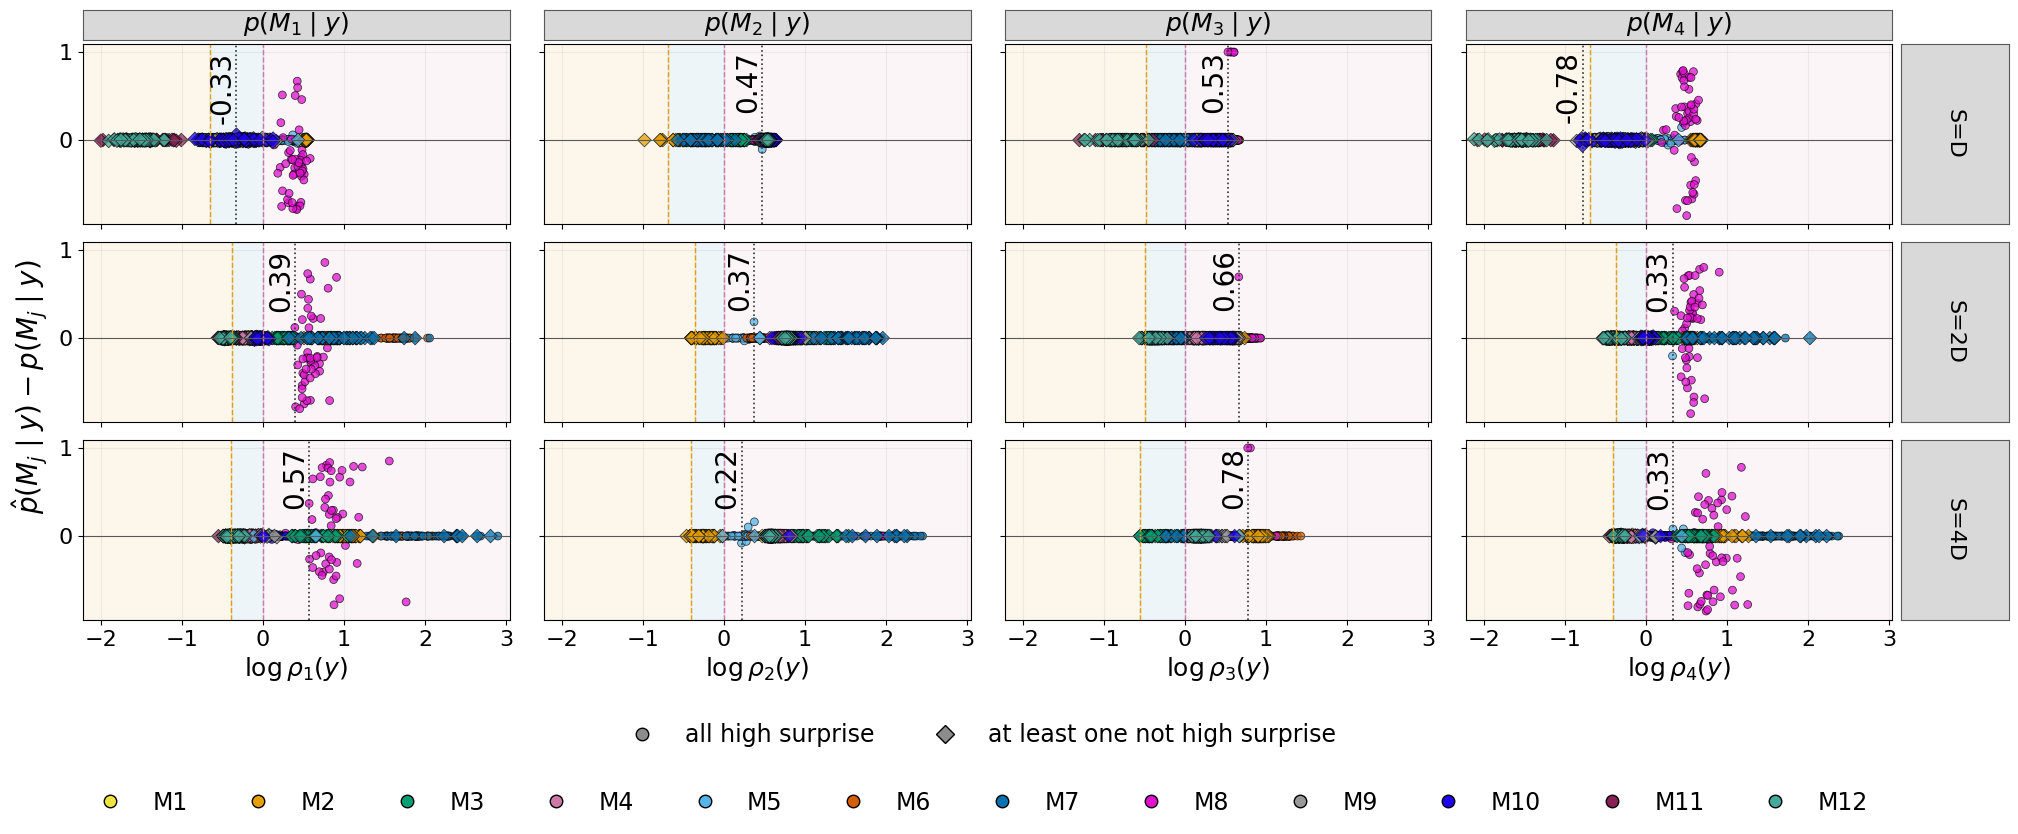

In [ ]:
def plot_combined_logrho_signed_error(pmp_by_summary, error_bound=0.05):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(pmp_by_summary)
    col_labels = [rf"$p(M_{model[1:]}\mid y)$" for model in assumed_models]
    x_min = -0.5
    x_max = 0.0
    for data in pmp_by_summary.values():
        for model in assumed_models:
            rho = data[f"d_{model}"] / data[f"dm_high_{model}"]
            log_rho = np.log(rho)
            x_min = min(x_min, float(log_rho.min()) * 1.05)
            x_max = max(x_max, float(log_rho.max()) * 1.05)

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 3.0 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    fig.subplots_adjust(left=0.07, right=0.94, bottom=0.24, top=0.88, wspace=0.08, hspace=0.10)

    for r, (row_label, data) in enumerate(pmp_by_summary.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            rho = data[f"d_{model}"] / data[f"dm_high_{model}"]
            x = np.log(rho)
            y = data[f"signed_pmp_error_npe_{model}"]
            low = float(np.log((data[f"dm_low_{model}"] / data[f"dm_high_{model}"]).iloc[0]))

            add_distance_regions(ax, low=low, high=0.0, x_min=x_min, x_max=x_max)
            scatter_by_class_and_source(ax, data, x, y)
            add_first_large_error(ax, data, x, y, error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xlim(x_min, x_max)

    xlabel_by_col = [rf"$\log \rho_{model[1:]}(y)$" for model in assumed_models]
    style_panel_grid(fig, axes, xlabel_by_col, r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$", row_labels, col_labels)
    return fig, axes


fig_logrho, axes_logrho = plot_combined_logrho_signed_error(pmp_by_summary)


## Sparse OOD metric comparison


In [ ]:

sparse_pmp_specs = {
    1: {
        "S=D\nsparse D=1, L2": result_dir / "ood_20d_10n_sparse1_l2" / "pmp_ambiguity_frame_20d_10n_sparse1_l2.csv",
        "S=D\nsparse D=1, Linf": result_dir / "ood_20d_10n_sparse1_linf" / "pmp_ambiguity_frame_20d_10n_sparse1_linf.csv",
    },
    3: {
        "S=D\nsparse D=3, L2": result_dir / "ood_20d_10n_sparse3_l2" / "pmp_ambiguity_frame_20d_10n_sparse3_l2.csv",
        "S=D\nsparse D=3, Linf": result_dir / "ood_20d_10n_sparse3_linf" / "pmp_ambiguity_frame_20d_10n_sparse3_linf.csv",
    },
}

sparse_pmp_by_dim = {
    sparse_dim: {label: pd.read_csv(path) for label, path in specs.items()}
    for sparse_dim, specs in sparse_pmp_specs.items()
}

for sparse_dim, frames in sparse_pmp_by_dim.items():
    for label, data in frames.items():
        print(f"sparse D={sparse_dim}: {label}", data.shape)


sparse D=1: S=D
sparse D=1, L2 (600, 50)
sparse D=1: S=D
sparse D=1, Linf (600, 50)
sparse D=3: S=D
sparse D=3, L2 (600, 50)
sparse D=3: S=D
sparse D=3, Linf (600, 50)


In [ ]:

def plot_sparse_rho_signed_error_log_scale(pmp_by_metric, error_bound=0.05):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(pmp_by_metric)
    col_labels = [rf"$p(M_{model[1:]}\mid y)$" for model in assumed_models]

    all_rho = []
    for data in pmp_by_metric.values():
        for model in assumed_models:
            rho = data[f"d_{model}"] / data[f"dm_high_{model}"]
            all_rho.append(rho[rho > 0].to_numpy())
    all_rho = np.concatenate(all_rho)
    x_min = float(all_rho.min() * 0.8)
    x_max = float(all_rho.max() * 1.15)

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 4.1 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.08, right=0.94, bottom=0.30, top=0.84, wspace=0.08, hspace=0.12)

    for r, (row_label, data) in enumerate(pmp_by_metric.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            x = data[f"d_{model}"] / data[f"dm_high_{model}"]
            y = data[f"signed_pmp_error_npe_{model}"]
            low = float((data[f"dm_low_{model}"] / data[f"dm_high_{model}"]).iloc[0])

            add_distance_regions(ax, low=low, high=1.0, x_min=x_min, x_max=x_max)
            scatter_by_class_and_source(ax, data, x, y)
            add_first_large_error(ax, data, x, y, error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xscale("log")
            ax.set_xlim(x_min, x_max)

    xlabel_by_col = [rf"$\rho_{model[1:]}(y)$" for model in assumed_models]
    style_panel_grid(
        fig,
        axes,
        xlabel_by_col,
        r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$",
        row_labels,
        col_labels,
    )
    return fig, axes


# Backward-compatible name for the cells below.
plot_sparse_logrho_signed_error = plot_sparse_rho_signed_error_log_scale


def plot_sparse_logA_signed_error(pmp_by_metric, error_bound=0.05):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(pmp_by_metric)
    col_labels = [rf"$p(M_{model[1:]}\mid y)$" for model in assumed_models]
    x_min = -0.5
    x_max = max(
        float(np.log1p(data["ambiguity_score"]).max()) * 1.05
        for data in pmp_by_metric.values()
    )

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 4.1 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.08, right=0.94, bottom=0.30, top=0.84, wspace=0.08, hspace=0.12)

    for r, (row_label, data) in enumerate(pmp_by_metric.items()):
        x = np.log1p(data["ambiguity_score"])
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            y = data[f"signed_pmp_error_npe_{model}"]
            scatter_by_class_and_source(ax, data, x, y)
            add_first_large_error(ax, data, x, y, error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xlim(x_min, x_max)

    style_panel_grid(
        fig,
        axes,
        [r"$\log(1+A(y))$"] * len(assumed_models),
        r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$",
        row_labels,
        col_labels,
    )
    return fig, axes


### 20d sparse OOD


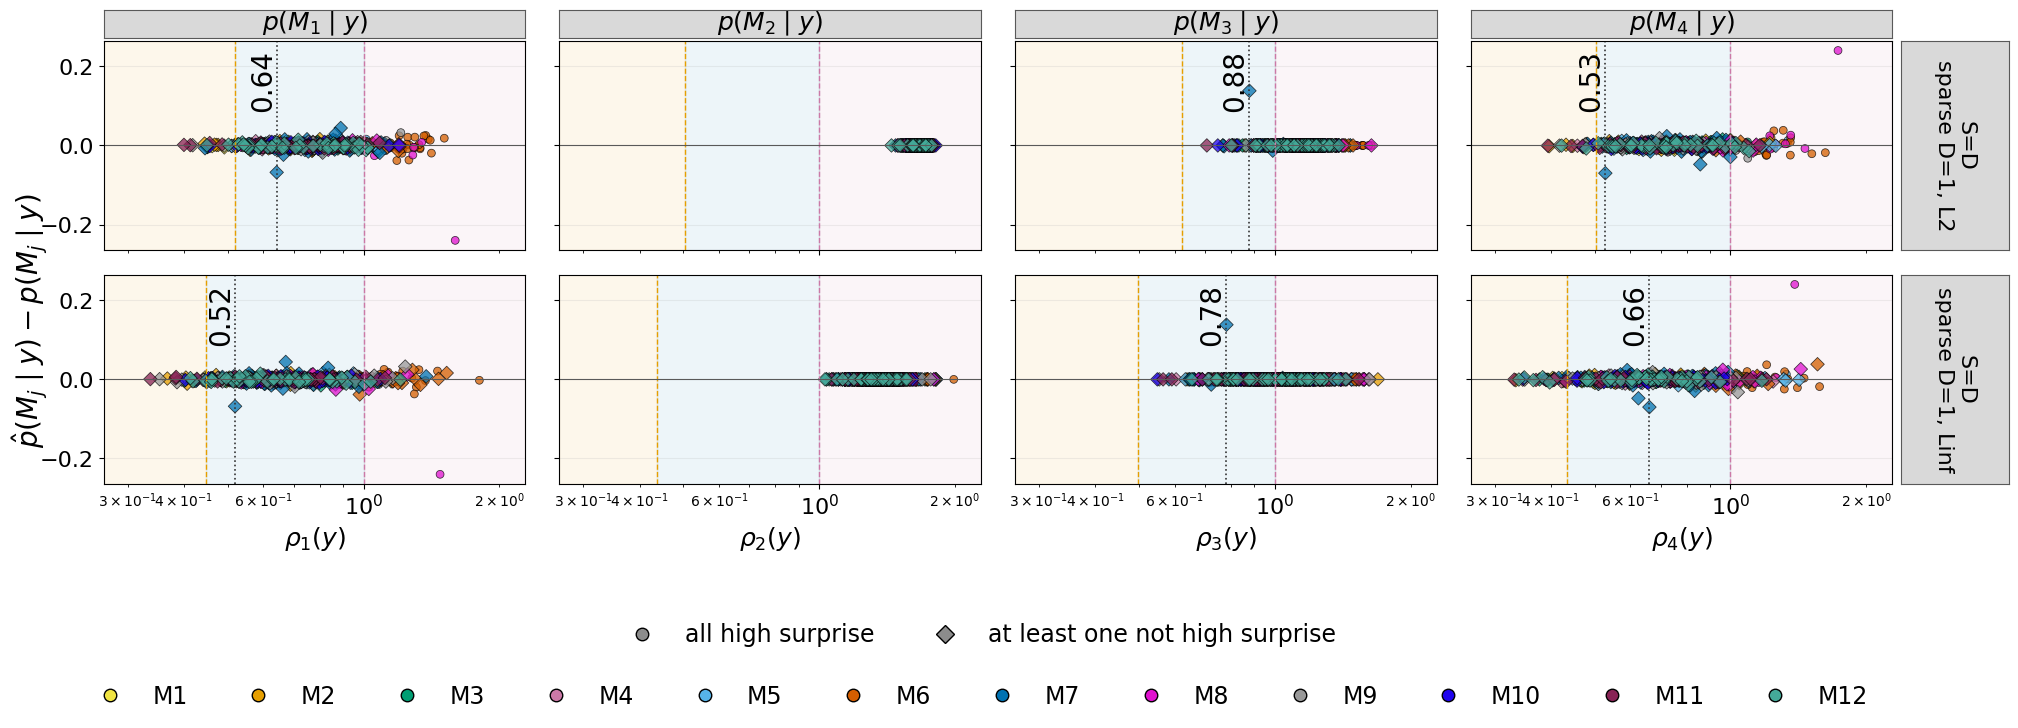

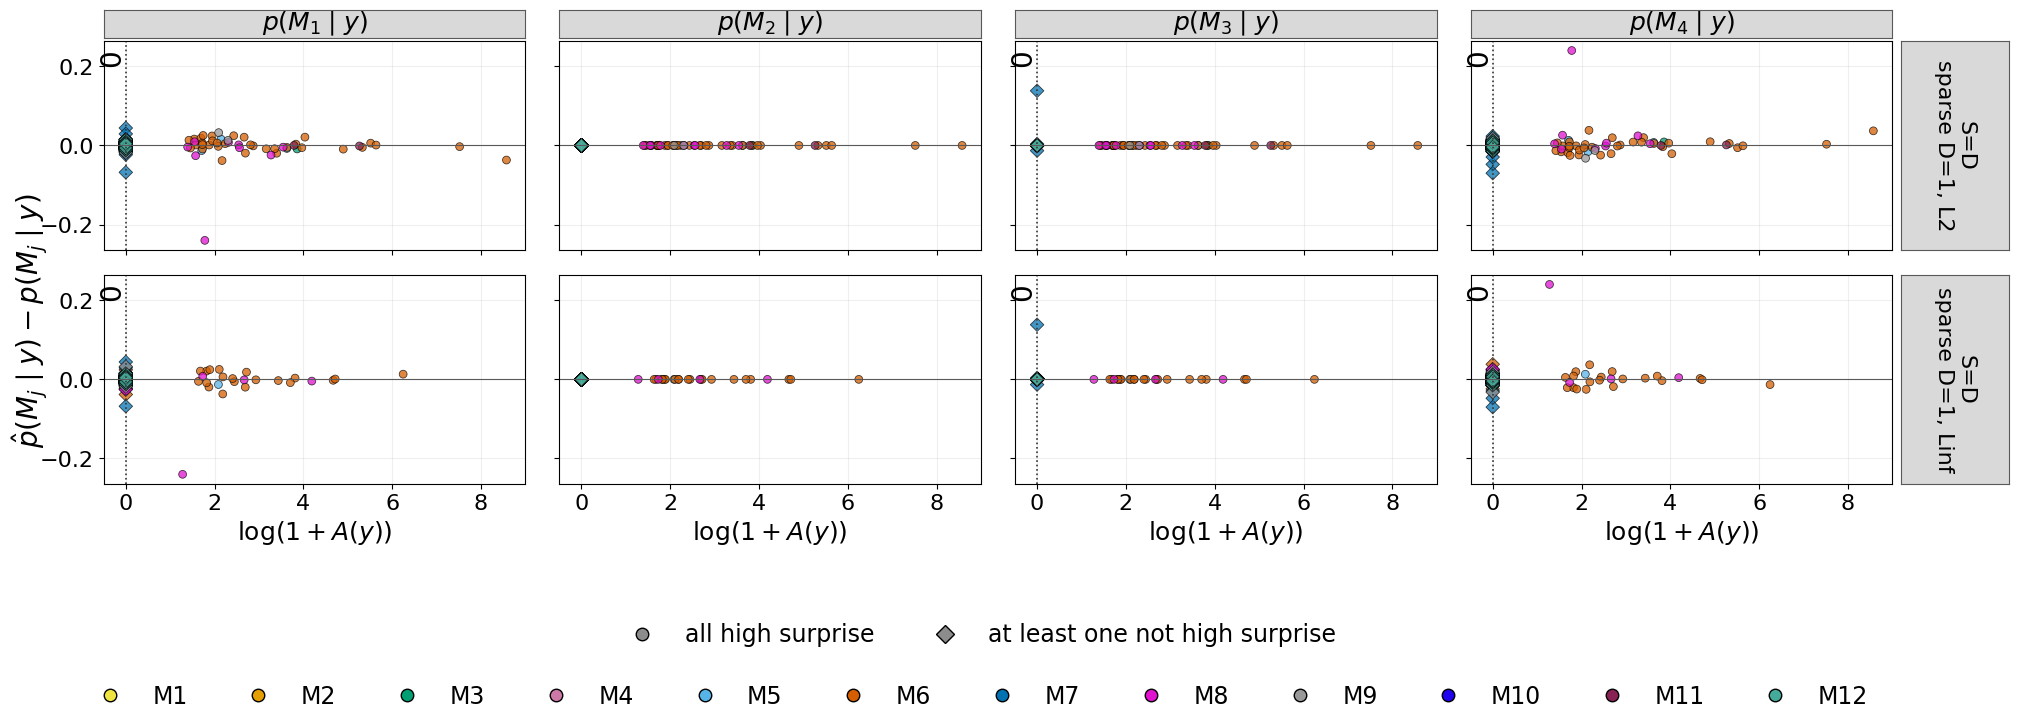

In [ ]:

fig_sparse1_logrho, axes_sparse1_logrho = plot_sparse_logrho_signed_error(sparse_pmp_by_dim[1])
fig_sparse1_logA, axes_sparse1_logA = plot_sparse_logA_signed_error(sparse_pmp_by_dim[1])


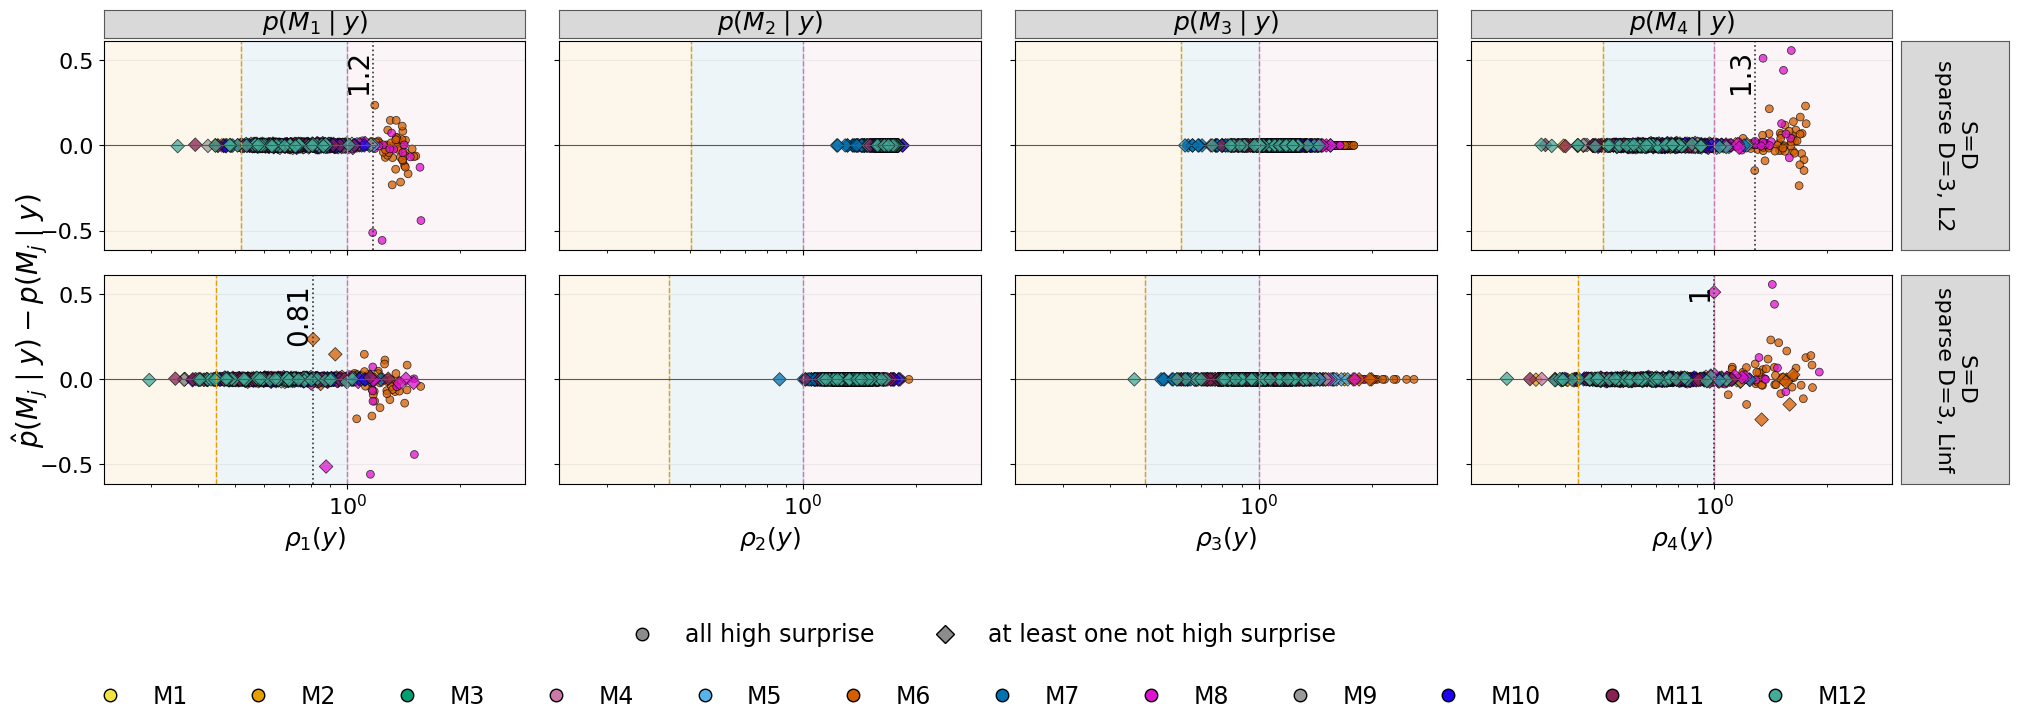

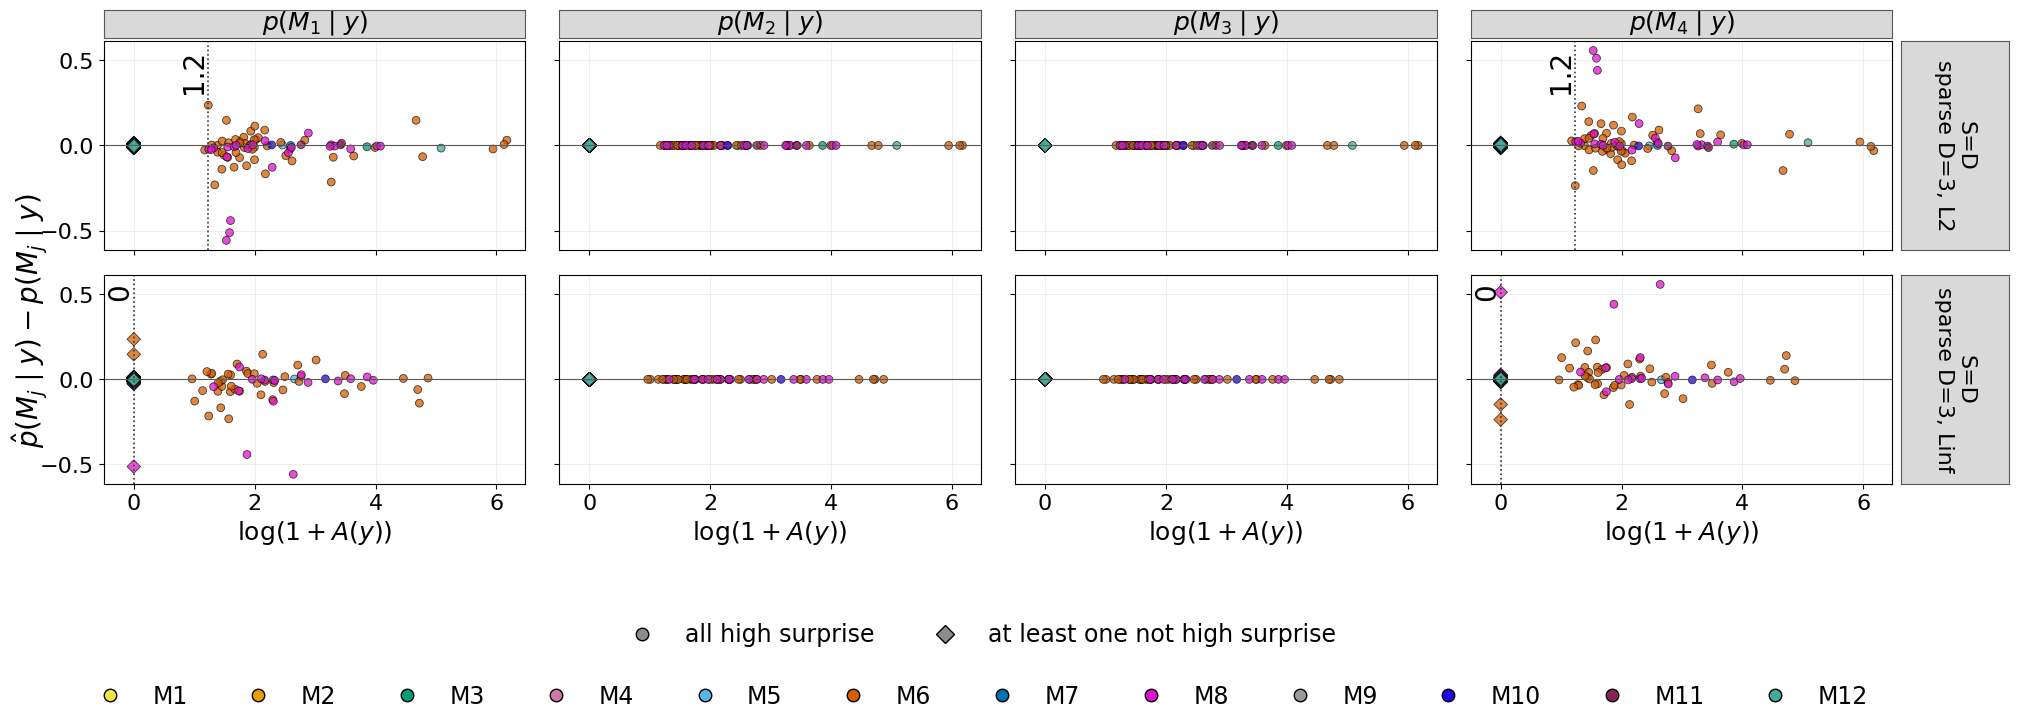

In [ ]:

fig_sparse3_logrho, axes_sparse3_logrho = plot_sparse_logrho_signed_error(sparse_pmp_by_dim[3])
fig_sparse3_logA, axes_sparse3_logA = plot_sparse_logA_signed_error(sparse_pmp_by_dim[3])


### 40d sparse OOD


In [ ]:

sparse_40d_pmp_specs = {
    1: {
        "S=2D\nsparse D=1, L2": result_dir / "ood_40d_10n_sparse1_l2" / "pmp_ambiguity_frame_40d_10n_sparse1_l2.csv",
        "S=2D\nsparse D=1, Linf": result_dir / "ood_40d_10n_sparse1_linf" / "pmp_ambiguity_frame_40d_10n_sparse1_linf.csv",
    },
    3: {
        "S=2D\nsparse D=3, L2": result_dir / "ood_40d_10n_sparse3_l2" / "pmp_ambiguity_frame_40d_10n_sparse3_l2.csv",
        "S=2D\nsparse D=3, Linf": result_dir / "ood_40d_10n_sparse3_linf" / "pmp_ambiguity_frame_40d_10n_sparse3_linf.csv",
    },
}

sparse_40d_pmp_by_dim = {
    sparse_dim: {label: pd.read_csv(path) for label, path in specs.items()}
    for sparse_dim, specs in sparse_40d_pmp_specs.items()
}

for sparse_dim, frames in sparse_40d_pmp_by_dim.items():
    for label, data in frames.items():
        print(f"40d sparse D={sparse_dim}: {label}", data.shape)


40d sparse D=1: S=2D
sparse D=1, L2 (600, 50)
40d sparse D=1: S=2D
sparse D=1, Linf (600, 50)
40d sparse D=3: S=2D
sparse D=3, L2 (600, 50)
40d sparse D=3: S=2D
sparse D=3, Linf (600, 50)


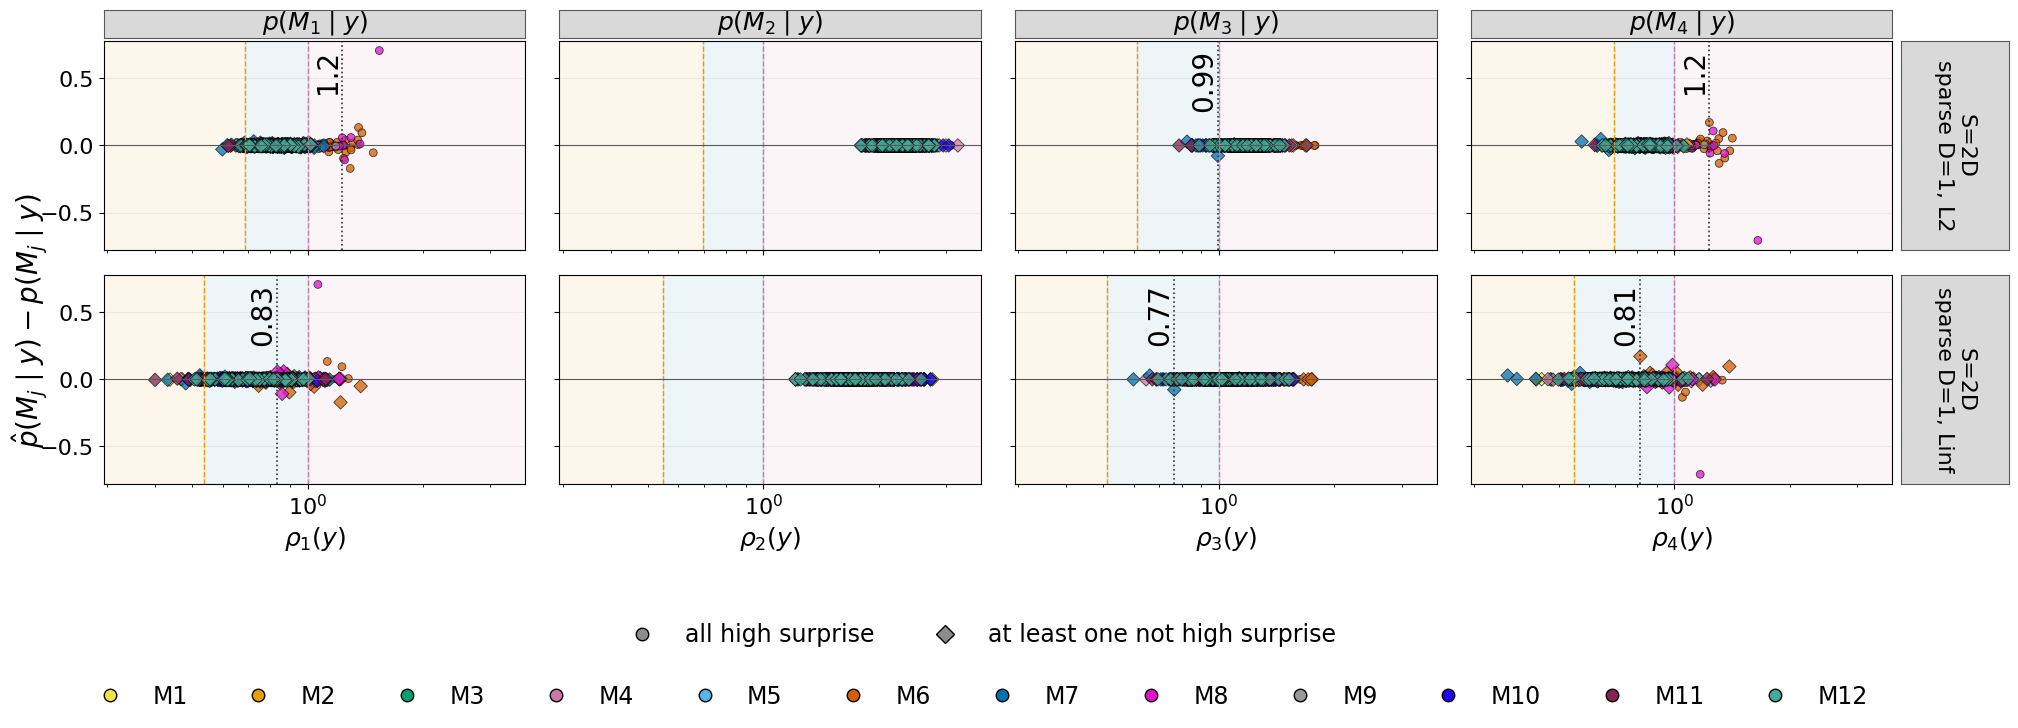

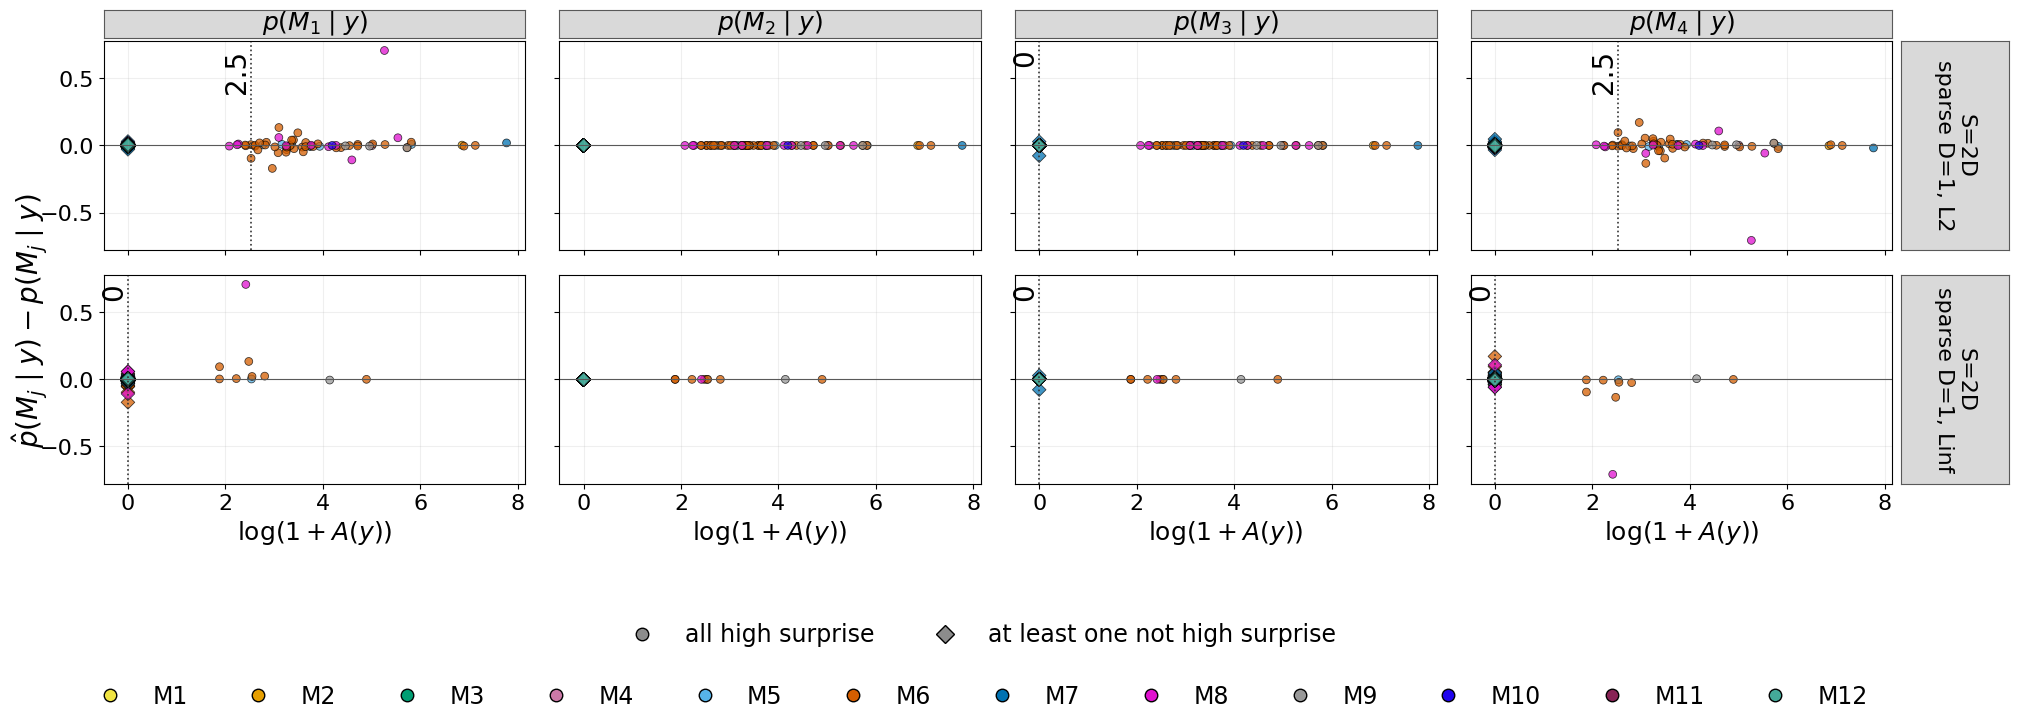

In [ ]:

fig_sparse1_40d_rho, axes_sparse1_40d_rho = plot_sparse_logrho_signed_error(sparse_40d_pmp_by_dim[1])
fig_sparse1_40d_logA, axes_sparse1_40d_logA = plot_sparse_logA_signed_error(sparse_40d_pmp_by_dim[1])


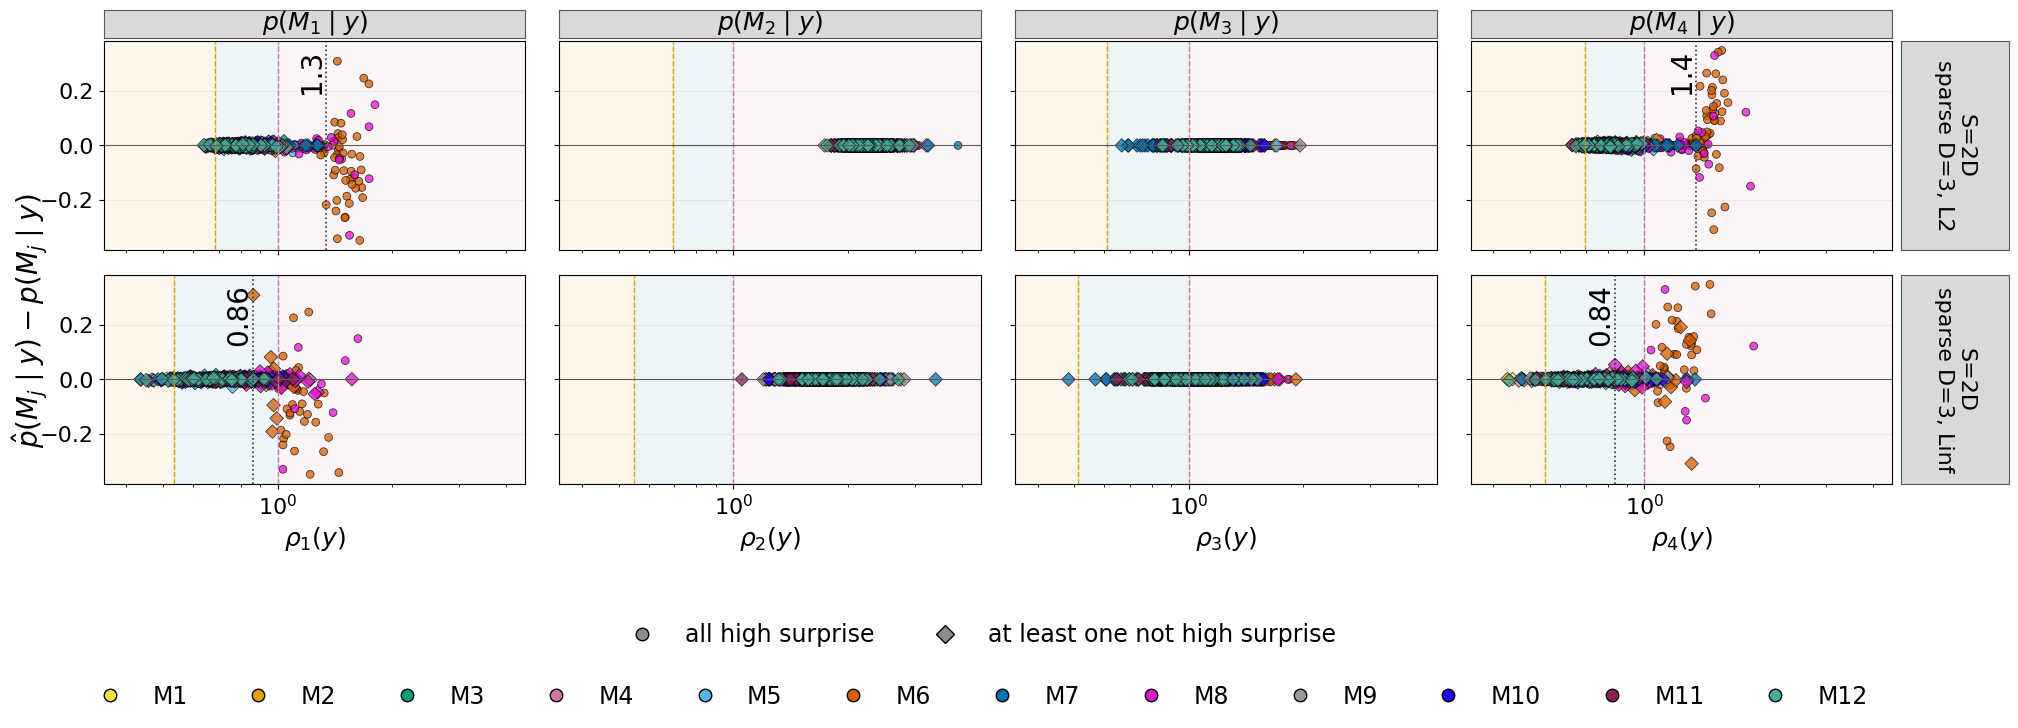

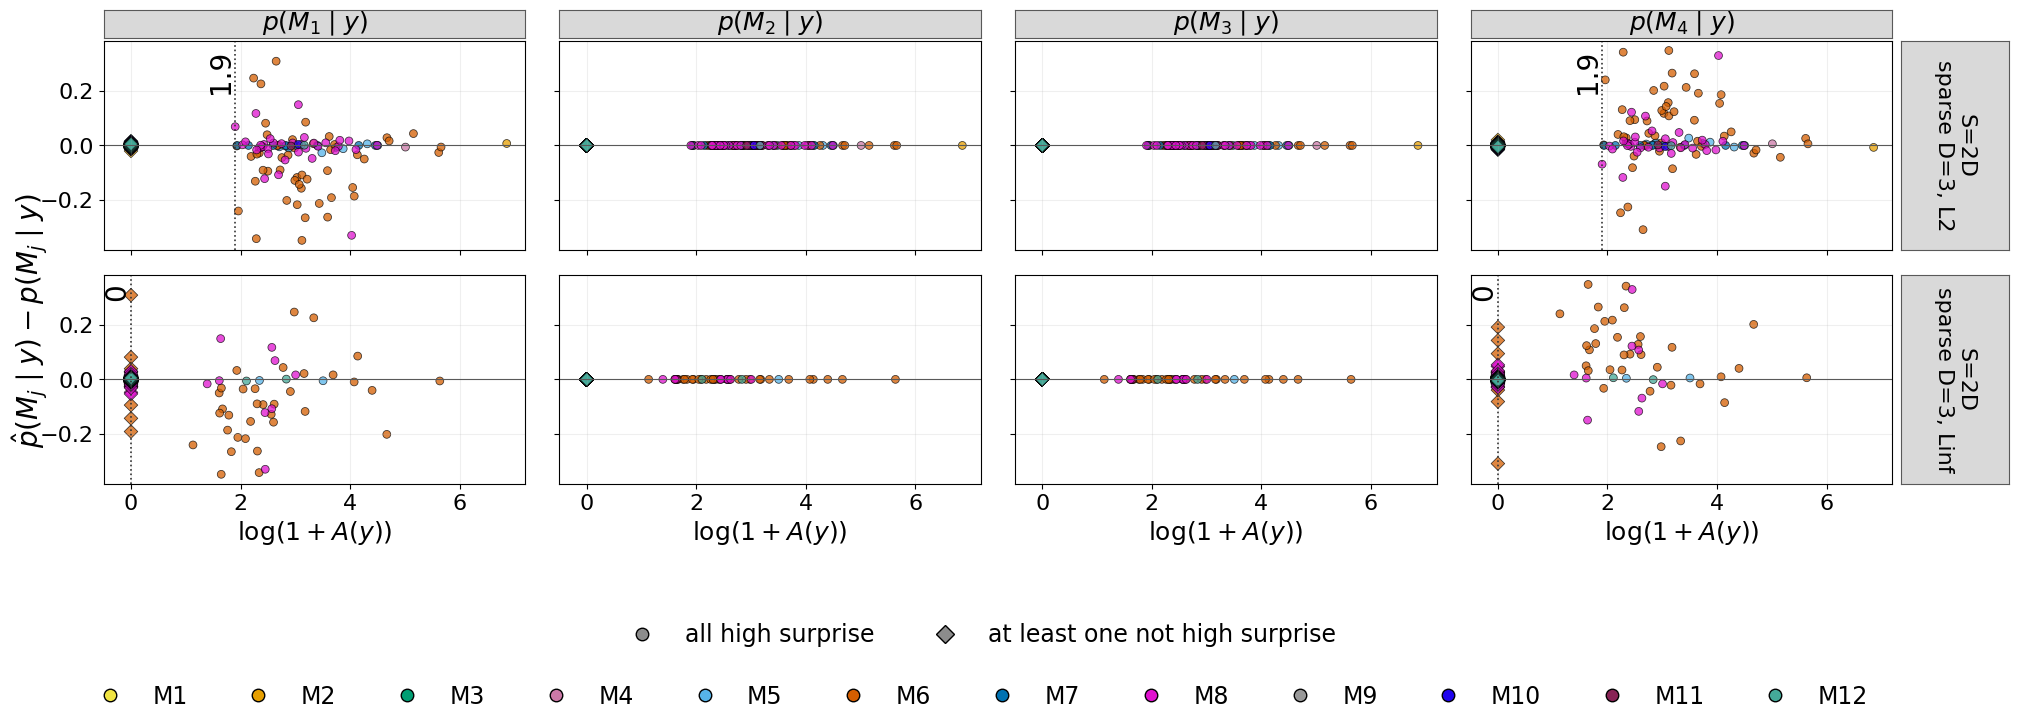

In [ ]:

fig_sparse3_40d_rho, axes_sparse3_40d_rho = plot_sparse_logrho_signed_error(sparse_40d_pmp_by_dim[3])
fig_sparse3_40d_logA, axes_sparse3_40d_logA = plot_sparse_logA_signed_error(sparse_40d_pmp_by_dim[3])


## L2 Summary-Dimension PMP Error


### L2: rho


Removed rho outliers above the 99% quantile: rho > 7.684


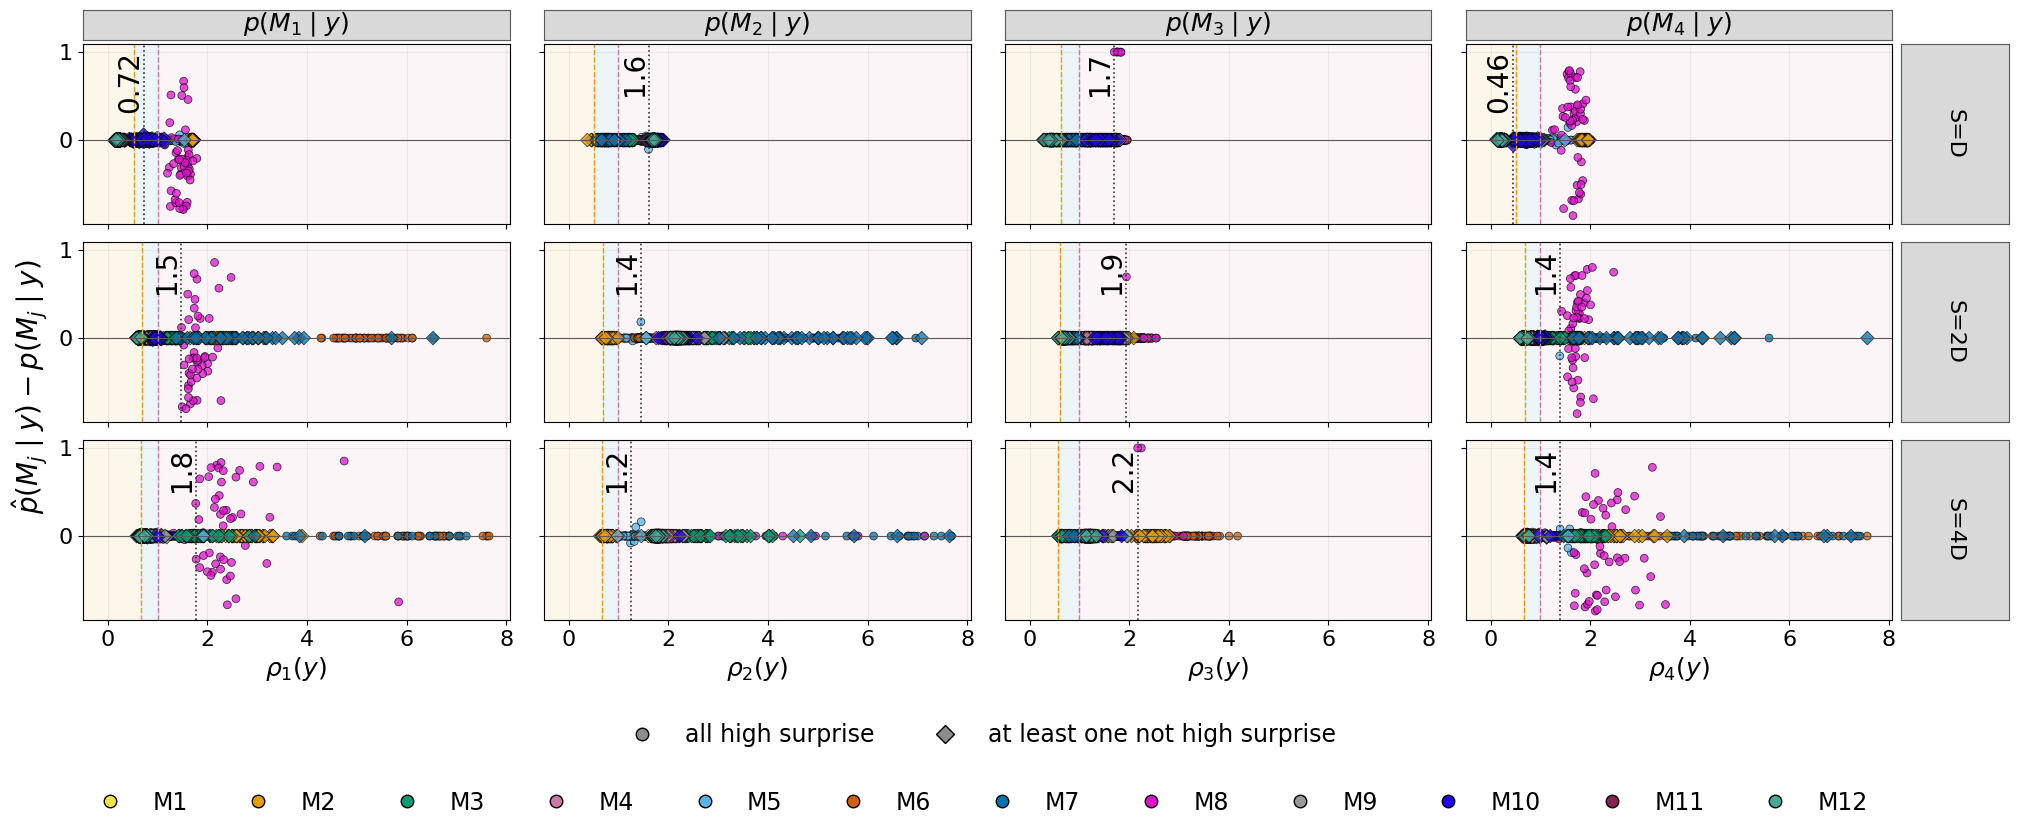

In [ ]:
def plot_combined_rho_signed_error_without_outliers(pmp_by_summary, error_bound=0.05, upper_quantile=0.99):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(pmp_by_summary)
    col_labels = [rf"$p(M_{model[1:]}\mid y)$" for model in assumed_models]
    x_min = -0.5

    all_rho = []
    for data in pmp_by_summary.values():
        for model in assumed_models:
            all_rho.append((data[f"d_{model}"] / data[f"dm_high_{model}"]).to_numpy())
    rho_cutoff = float(np.quantile(np.concatenate(all_rho), upper_quantile))
    x_max = rho_cutoff * 1.05

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 3.0 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    fig.subplots_adjust(left=0.07, right=0.94, bottom=0.24, top=0.88, wspace=0.08, hspace=0.10)

    for r, (row_label, data) in enumerate(pmp_by_summary.items()):
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            rho = data[f"d_{model}"] / data[f"dm_high_{model}"]
            keep = rho <= rho_cutoff
            plot_data = data[keep]
            x = rho[keep]
            y = data.loc[keep, f"signed_pmp_error_npe_{model}"]
            low = float((data[f"dm_low_{model}"] / data[f"dm_high_{model}"]).iloc[0])

            add_distance_regions(ax, low=low, high=1.0, x_min=x_min, x_max=x_max)
            scatter_by_class_and_source(ax, plot_data, x, y)
            add_first_large_error(ax, plot_data, x, y, error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xlim(x_min, x_max)

    xlabel_by_col = [rf"$\rho_{model[1:]}(y)$" for model in assumed_models]
    style_panel_grid(fig, axes, xlabel_by_col, r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$", row_labels, col_labels)
    return fig, axes, rho_cutoff


fig_rho_trimmed, axes_rho_trimmed, rho_outlier_cutoff = plot_combined_rho_signed_error_without_outliers(pmp_by_summary)
print(f"Removed rho outliers above the {0.99:.0%} quantile: rho > {rho_outlier_cutoff:.3f}")


### L2: A(y)


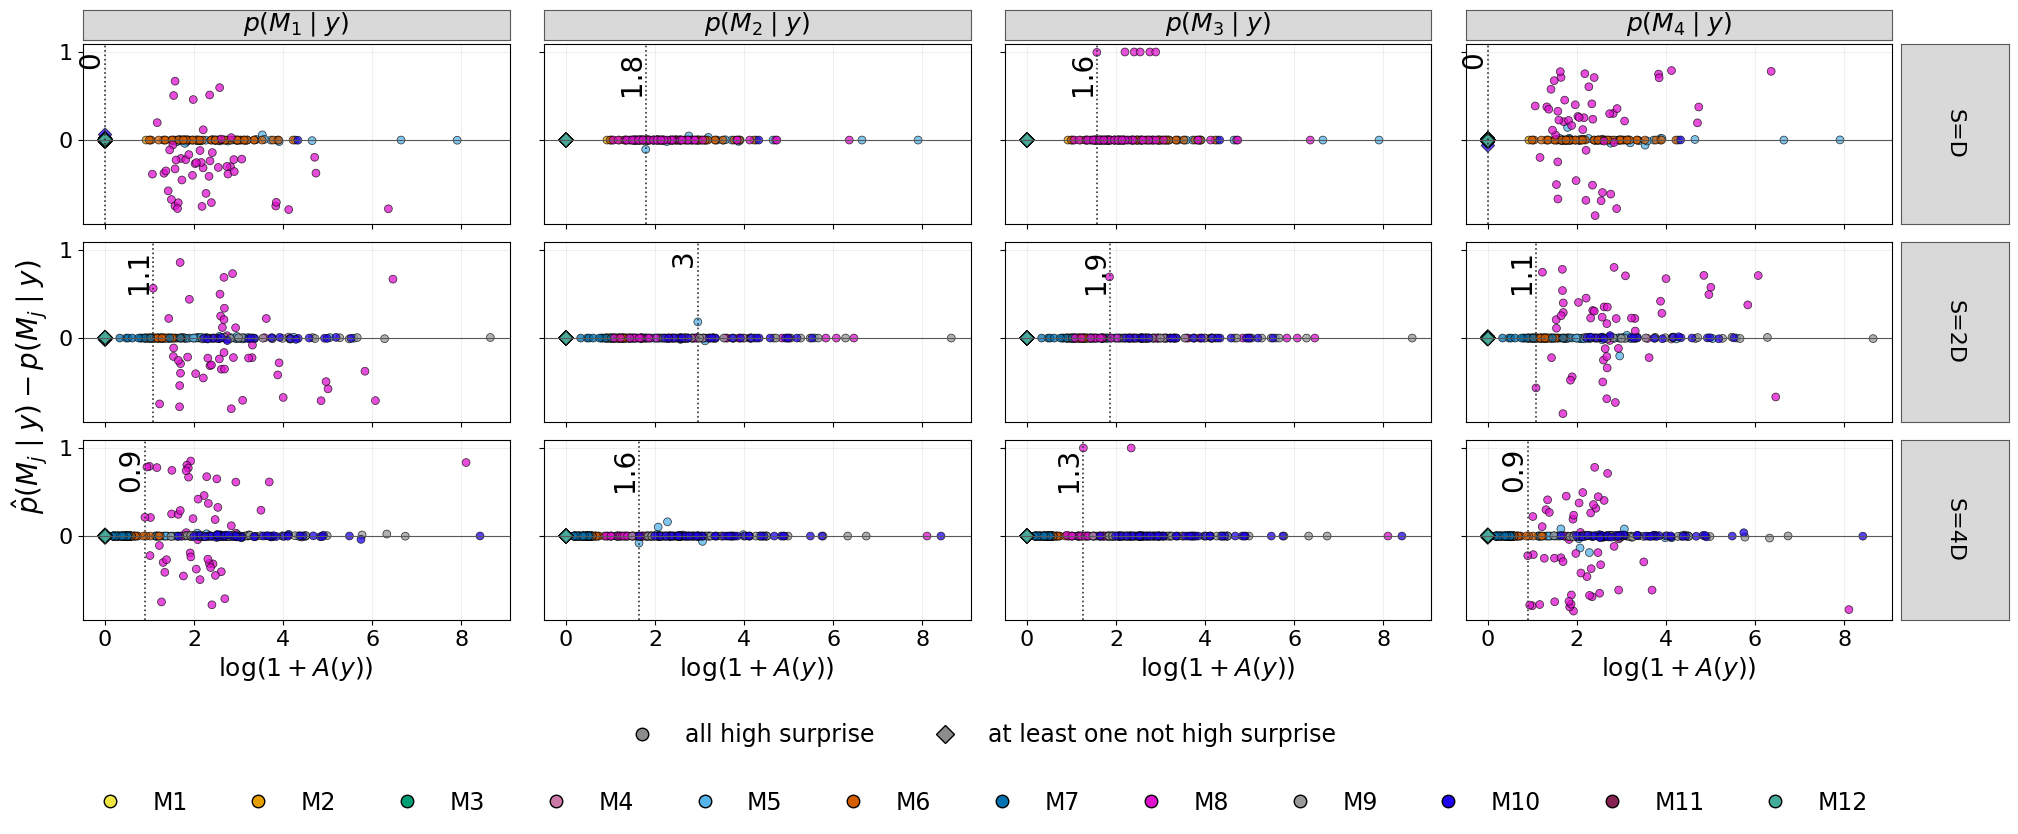

In [ ]:

def plot_combined_logA_signed_error(pmp_by_summary, error_bound=0.05):
    assumed_models = sd.ASSUMED_MODELS
    row_labels = list(pmp_by_summary)
    col_labels = [rf"$p(M_{model[1:]}\mid y)$" for model in assumed_models]
    x_min = -0.5
    x_max = max(
        float(np.log1p(data["ambiguity_score"]).max()) * 1.05
        for data in pmp_by_summary.values()
    )

    fig, axes = plt.subplots(
        len(row_labels),
        len(assumed_models),
        figsize=(4.4 * len(assumed_models) + 3.2, 3.0 * len(row_labels)),
        sharex=True,
        sharey=True,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.07, right=0.94, bottom=0.24, top=0.88, wspace=0.08, hspace=0.10)

    for r, (row_label, data) in enumerate(pmp_by_summary.items()):
        x = np.log1p(data["ambiguity_score"])
        for c, model in enumerate(assumed_models):
            ax = axes[r, c]
            y = data[f"signed_pmp_error_npe_{model}"]
            scatter_by_class_and_source(ax, data, x, y)
            add_first_large_error(ax, data, x, y, error_bound=error_bound)
            ax.axhline(0, color="0.35", linewidth=0.8)
            ax.set_xlim(x_min, x_max)

    style_panel_grid(
        fig,
        axes,
        [r"$\log(1+A(y))$"] * len(assumed_models),
        r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$",
        row_labels,
        col_labels,
    )
    return fig, axes


fig_logA_final, axes_logA_final = plot_combined_logA_signed_error(pmp_by_summary)


## Linf Summary-Dimension PMP Error


In [ ]:

linf_summary_specs = [
    ("S=D, Linf", "20d_10n_linf", result_dir / "ood_20d_10n_inf"),
    ("S=2D, Linf", "40d_10n_linf", result_dir / "ood_40d_10n_inf"),
    ("S=4D, Linf", "80d_10n_linf", result_dir / "ood_80d_10n_inf"),
]

pmp_by_summary_linf = {
    label: pd.read_csv(path / f"pmp_ambiguity_frame_{tag}.csv")
    for label, tag, path in linf_summary_specs
}

for label, df in pmp_by_summary_linf.items():
    print(label, "pmp", df.shape)


S=D, Linf pmp (600, 50)
S=2D, Linf pmp (600, 50)
S=4D, Linf pmp (600, 50)


Linf: removed rho outliers above the 99% quantile: rho > 5.997


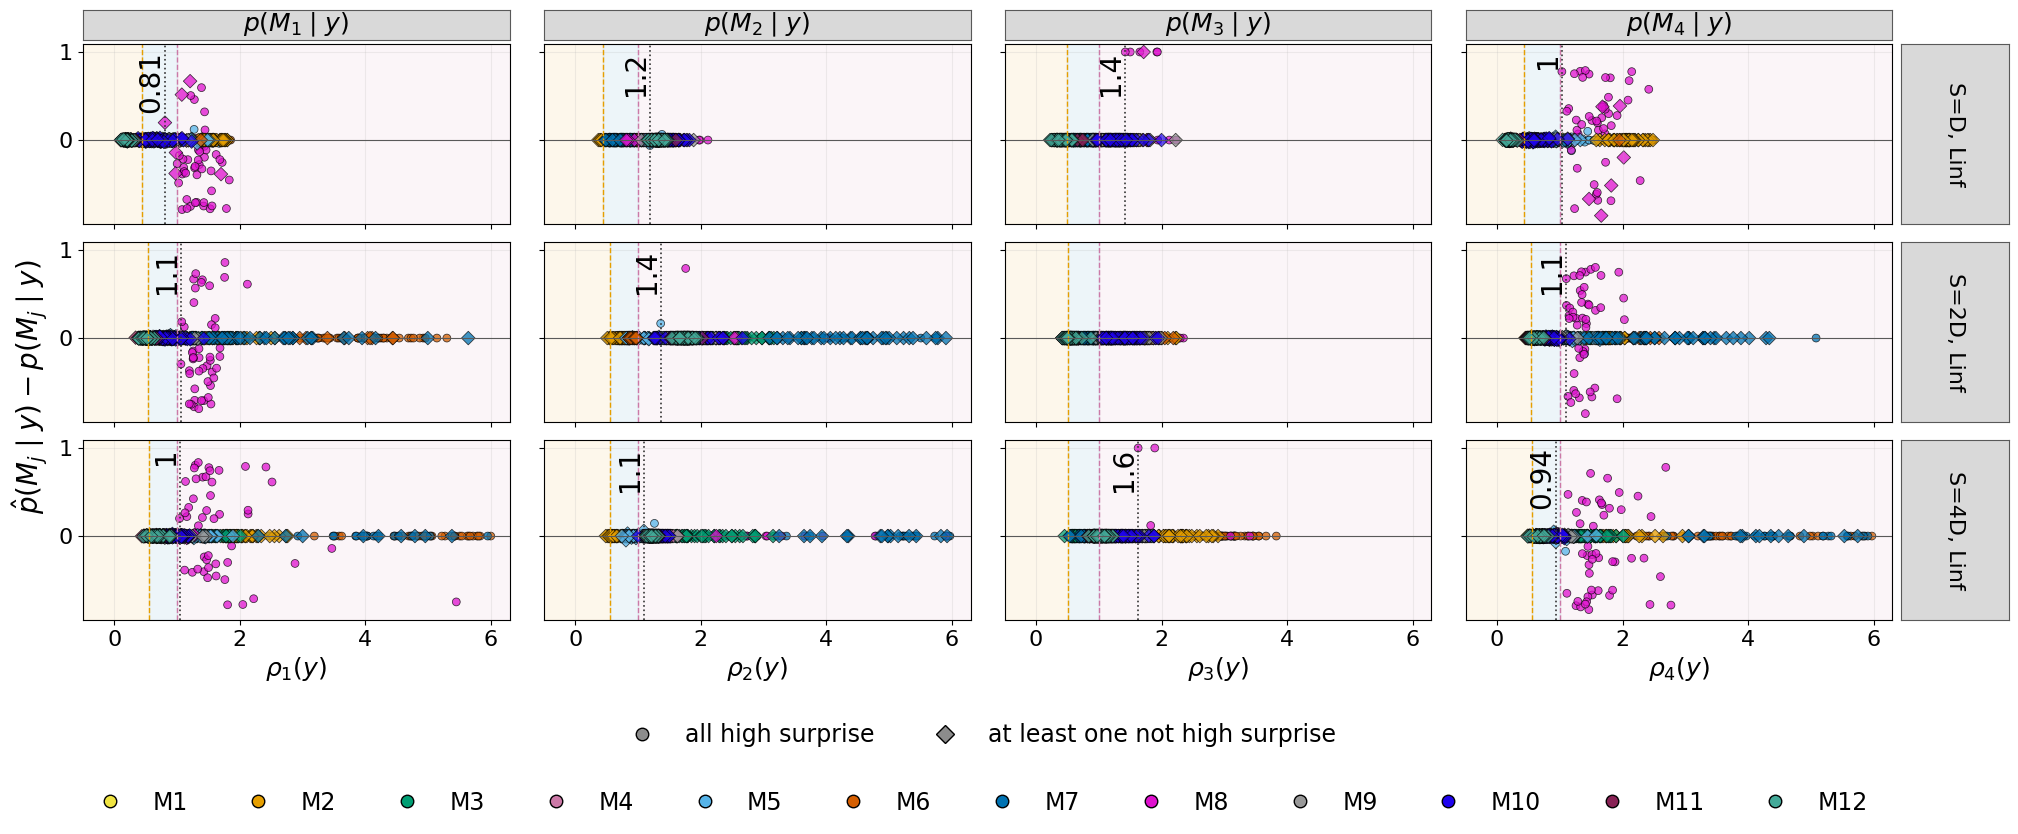

In [ ]:

fig_rho_trimmed_linf, axes_rho_trimmed_linf, rho_outlier_cutoff_linf = plot_combined_rho_signed_error_without_outliers(
    pmp_by_summary_linf
)
print(f"Linf: removed rho outliers above the {0.99:.0%} quantile: rho > {rho_outlier_cutoff_linf:.3f}")


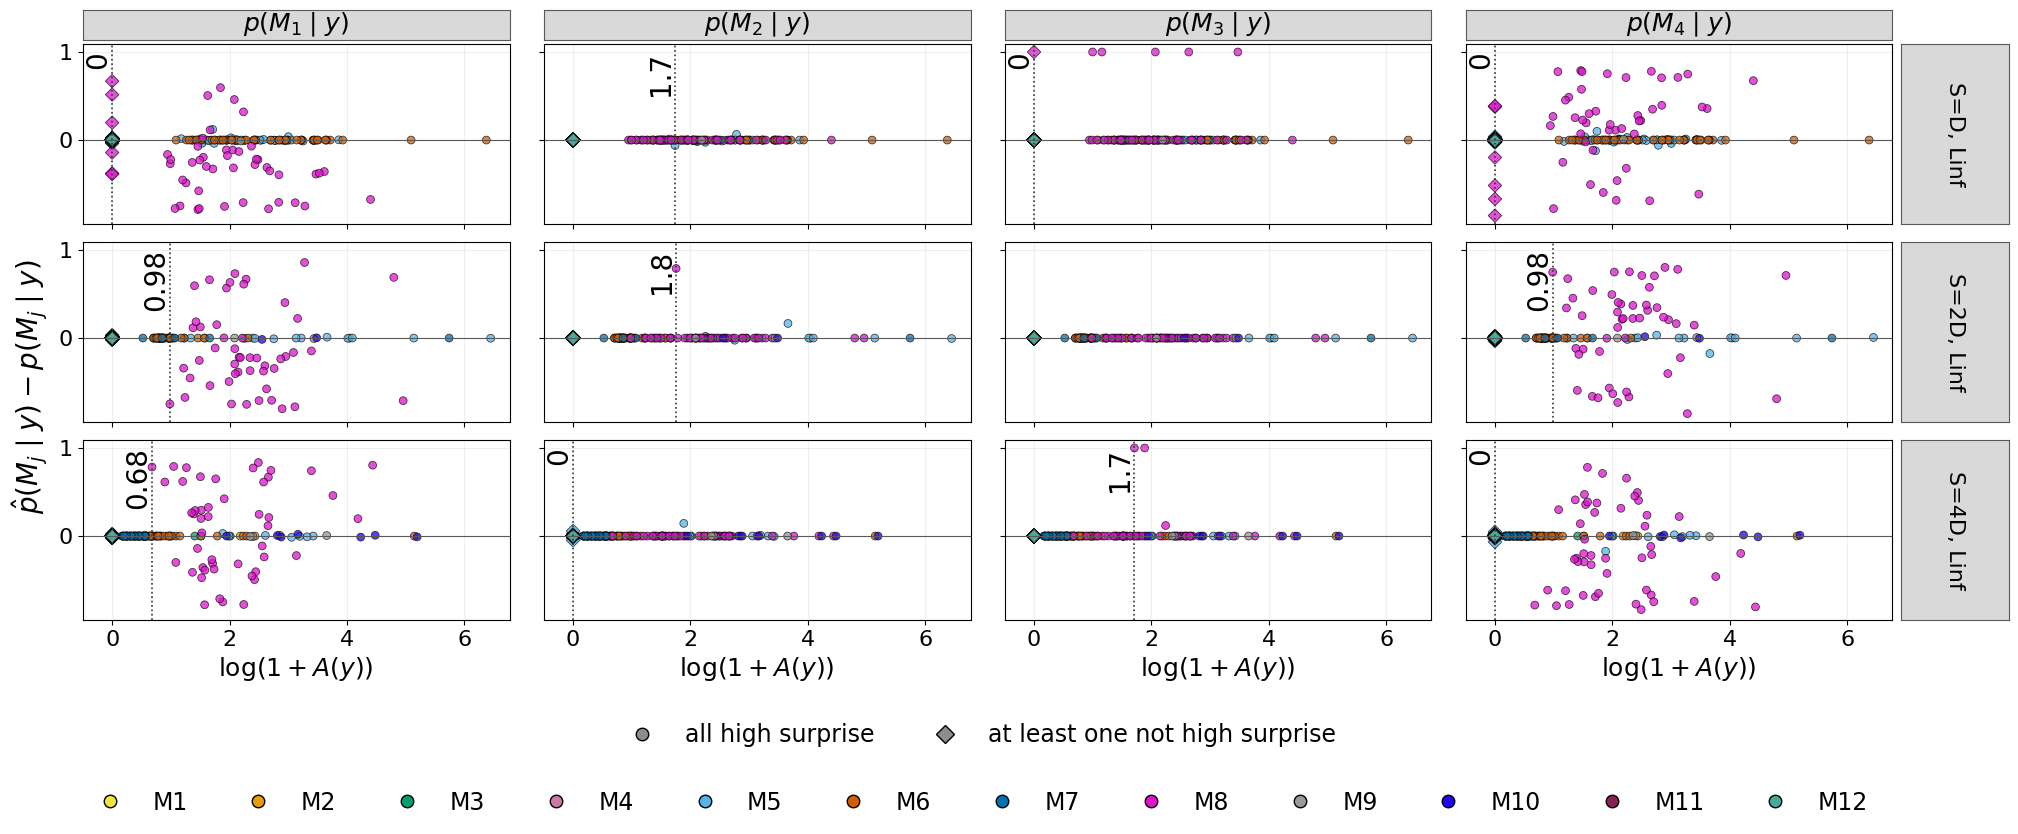

In [ ]:

fig_logA_linf, axes_logA_linf = plot_combined_logA_signed_error(pmp_by_summary_linf)
